# Credit Default Prediction Using Sequential Feature Selection

##  Project Overview

This project develops a machine learning model for predicting credit card
payment default while systematically reducing the original **23 predictor
features to 15 informative features**.

Feature selection is performed sequentially using:

1. **Correlation Filtering** — removes highly correlated and redundant features.
2. **Information Value (IV)** — evaluates the predictive strength of the remaining features.
3. **SHAP Feature Importance** — analyzes how strongly each feature contributes to model predictions.

A **LightGBM classifier** is evaluated after each feature-selection stage using
Train ROC-AUC and Test ROC-AUC to measure how feature reduction affects
predictive performance.

Finally, six classification algorithms are tuned and compared:

- Logistic Regression
- Random Forest
- AdaBoost
- LightGBM
- CatBoost
- XGBoost

The final model is selected primarily based on **Test ROC-AUC**.

 ## 1.  Importing Libraries

The required libraries are imported for data manipulation, visualization,
preprocessing, feature selection, model training, hyperparameter tuning,
evaluation, and model explainability.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
import warnings
warnings.filterwarnings("ignore")

# Train-test splitting and tuning
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.impute import (
    SimpleImputer
)

# Feature predictive power
from sklearn.feature_selection import mutual_info_classif

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier
)

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Explainability
import shap

# Reproducibility
RANDOM_STATE = 42

## 2. About the Dataset

The **Default of Credit Card Clients** dataset is a publicly available
credit-scoring dataset used to predict whether a customer will default on
their next credit card payment.

The dataset contains **30,000 customer records** and **23 predictor features**
covering:

- Credit limit
- Demographic information
- Repayment history
- Monthly bill amounts
- Previous payment amounts

The target variable, **`default payment next month`**, indicates whether a
customer defaulted on the following month's payment:

- **0** -> No Default
- **1** -> Default

This makes the problem a **binary classification task**.

## 3. Loading the Dataset

The dataset is loaded into a Pandas DataFrame. Since the original CSV file
contains an additional header row, `header=1` is used to correctly identify
the column names.

The first five records are displayed to verify that the dataset has been
loaded successfully.

In [2]:
df = pd.read_csv("credit_scoring.csv", header=1)
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


### 3.1 Dataset Dimensions

The dimensions of the dataset are examined to determine the total number
of observations and variables.

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 30000
Number of columns: 25


**Observation:**  
The dataset contains **30,000 customer records and 25 columns**.
The columns consist of the customer ID, 23 predictor features, and the
target variable.

### 3.2 Column Names

The column names are inspected to understand the variables available
for analysis and to identify the target and identifier columns.

In [4]:
print(df.columns.tolist())

['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


### 3.3 Dataset Information

The structure of the dataset is examined using `df.info()` to inspect
column data types, non-null counts, and memory usage

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_AMT3        

**Observation:**  
All 25 columns contain **30,000 non-null observations** and are stored as
integer (`int64`) values. This initial inspection also indicates that there
are no immediately visible missing values.

### 3.4 Statistical Summary

Descriptive statistics are generated for all numerical variables to examine
their central tendency, variability, and value ranges.

This provides an initial understanding of the distributions of credit limits,
customer ages, repayment status, bill amounts, payment amounts, and the
target variable.

In [6]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


**Observation:**  
The features operate on very different numerical scales. For example,
`LIMIT_BAL`, bill amounts, and payment amounts contain substantially larger
values than demographic and repayment-status variables.

The target variable has a mean of approximately **0.2212**, suggesting that
about **22% of the customers defaulted**. The class distribution will be
examined more explicitly later.

### 3.5 Missing Value Analysis

Missing values are checked for every column by calculating both the total
number and percentage of missing observations.

Identifying missing data at this stage is important because incomplete
observations may affect feature selection and model performance.

In [7]:
missing_values = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().mean() * 100
    ).round(2)
})

display(
    missing_values.sort_values(
        by="Missing Count",
        ascending=False
    )
)
print(
    "Total missing values:",
    df.isnull().sum().sum()
)

,Missing Count,Missing Percentage
ID,0,0.0
LIMIT_BAL,0,0.0
SEX,0,0.0
EDUCATION,0,0.0
MARRIAGE,0,0.0
AGE,0,0.0
PAY_0,0,0.0
PAY_2,0,0.0
PAY_3,0,0.0
PAY_4,0,0.0


Total missing values: 0


**Observation:**  
No missing values were detected in the dataset. Therefore, no missing-value
imputation is required before continuing with the analysis.

### 3.6 Duplicate Value Analysis

Duplicate observations are checked to ensure that repeated records do not
unnecessarily influence the analysis or model training.

In [8]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


**Observation:**  
The dataset contains **0 duplicate rows**, so no duplicate removal is required.

### 3.7 Unique Value Analysis

The number of unique values in each column is examined to better understand
the structure of the features and identify variables that behave as
identifiers, categorical variables, or continuous numerical variables.

In [9]:
unique_summary = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": [
        df[column].nunique()
        for column in df.columns
    ]
})

display(unique_summary)

,Column,Unique Values
0,ID,30000
1,LIMIT_BAL,81
2,SEX,2
3,EDUCATION,7
4,MARRIAGE,4
5,AGE,56
6,PAY_0,11
7,PAY_2,11
8,PAY_3,11
9,PAY_4,11


**Observation:**  
`ID` contains **30,000 unique values**, confirming that it functions as a
customer identifier rather than a meaningful predictive feature.

Several demographic and repayment variables contain relatively few unique
values, while bill and payment amount variables contain substantially more.
The target variable contains exactly **two classes**, confirming the binary
classification structure of the problem.

### 4. Defining the Target and Predictor Features

Before model training, the dataset is separated into the target variable (y) and the predictor features (X).

The ID column is removed because it is only a unique customer identifier and does not provide meaningful predictive information.

The target column, default payment next month, represents whether a customer defaulted on their next payment:

0 -> No Default

1 -> Default

In [10]:
# Define the name of the target variable
TARGET_COLUMN = "default payment next month"

# Define the ID column to be removed
ID_COLUMN = "ID"

# Create the feature matrix (X) by removing the ID and target columns
X = df.drop(
    columns=[
        ID_COLUMN,
        TARGET_COLUMN
    ]
).copy()
# Create the target vector (y)
y = df[TARGET_COLUMN].copy()

# Display the number of predictor features
print("Number of features:", X.shape[1])

# Display the target variable name
print("Target name:", TARGET_COLUMN)

Number of features: 23
Target name: default payment next month


 **Observation**  

After removing the ID and target columns, the feature matrix contains 30,000 observations and 23 predictor features.

The target contains 30,000 corresponding observations, confirming that the features and target are correctly aligned.

## Check Target Values

In [11]:
## Display the unique classes present in the target variable
print("Unique target values:", y.unique())
print()

# Display the number of samples belonging to each class
print(y.value_counts())

# Convert the target variable to numeric values
# Raise an error if any non-numeric values are found
y = pd.to_numeric(
    y,
    errors="raise"
).astype(int)
# Convert the numeric values to integers (0 and 1)

Unique target values: [1 0]

default payment next month
0    23364
1     6636
Name: count, dtype: int64


### 4.1 Target Class Distribution

The distribution of the target variable is examined to determine the proportion of customers who defaulted and those who did not.

Understanding the class distribution is important because a significant imbalance between the two classes can influence model evaluation and prediction behavior.

In [12]:
# Create a DataFrame containing the class counts and percentages
target_distribution = pd.DataFrame({
     # Count the number of samples in each target class
    "Count": y.value_counts(),
    # Calculate the percentage of each target class
    "Percentage": (
        y.value_counts(normalize=True) * 100
    ).round(2)# Round percentages to 2 decimal places
})

# Rename the index for better table presentation
target_distribution.index.name = "Default Class"

# Display the target distribution table
display(target_distribution)

,Count,Percentage
Default Class,,
0,23364,77.88
1,6636,22.12


###  Observation

The target variable is **imbalanced**, with substantially more non-default customers than default customers.

Approximately **22% of the observations represent customers who defaulted**, while the remaining observations represent non-default customers.

Because of this imbalance, model performance should not be judged using accuracy alone. Metrics such as **ROC-AUC, Precision, Recall, and F1-score** provide additional information about classification performance.

### 4.2 Feature Distribution Analysis

Histograms are used to examine the distributions of the numerical predictor variables.

This helps identify skewed distributions, unusual value ranges, concentration patterns, and potential outliers before feature selection and model training.

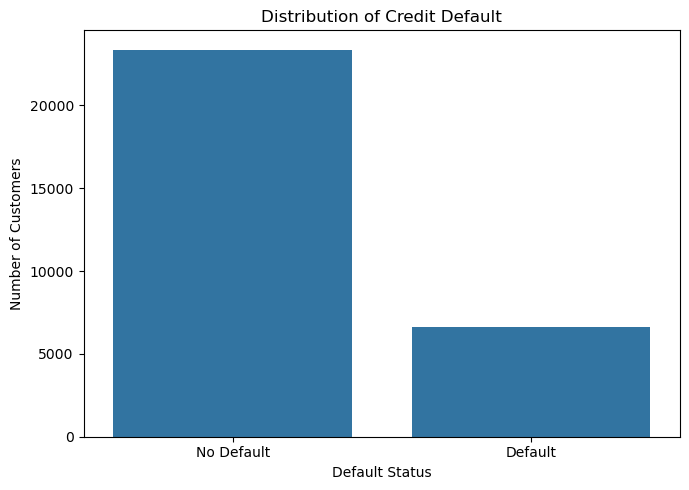

In [13]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x=y
)

plt.title("Distribution of Credit Default")
plt.xlabel("Default Status")
plt.ylabel("Number of Customers")
plt.xticks(
    ticks=[0, 1],
    labels=[
        "No Default",
        "Default"
    ]
)

plt.tight_layout()
plt.show()

###  Observation

The predictor variables have noticeably different distributions and numerical ranges.

Credit limits, bill amounts, and payment amounts show wider ranges, while demographic and repayment-status variables are concentrated within a smaller set of values.

These differences are important when comparing different machine learning algorithms because some models are more sensitive to feature scale than tree-based methods.

## Numerical Feature Histograms

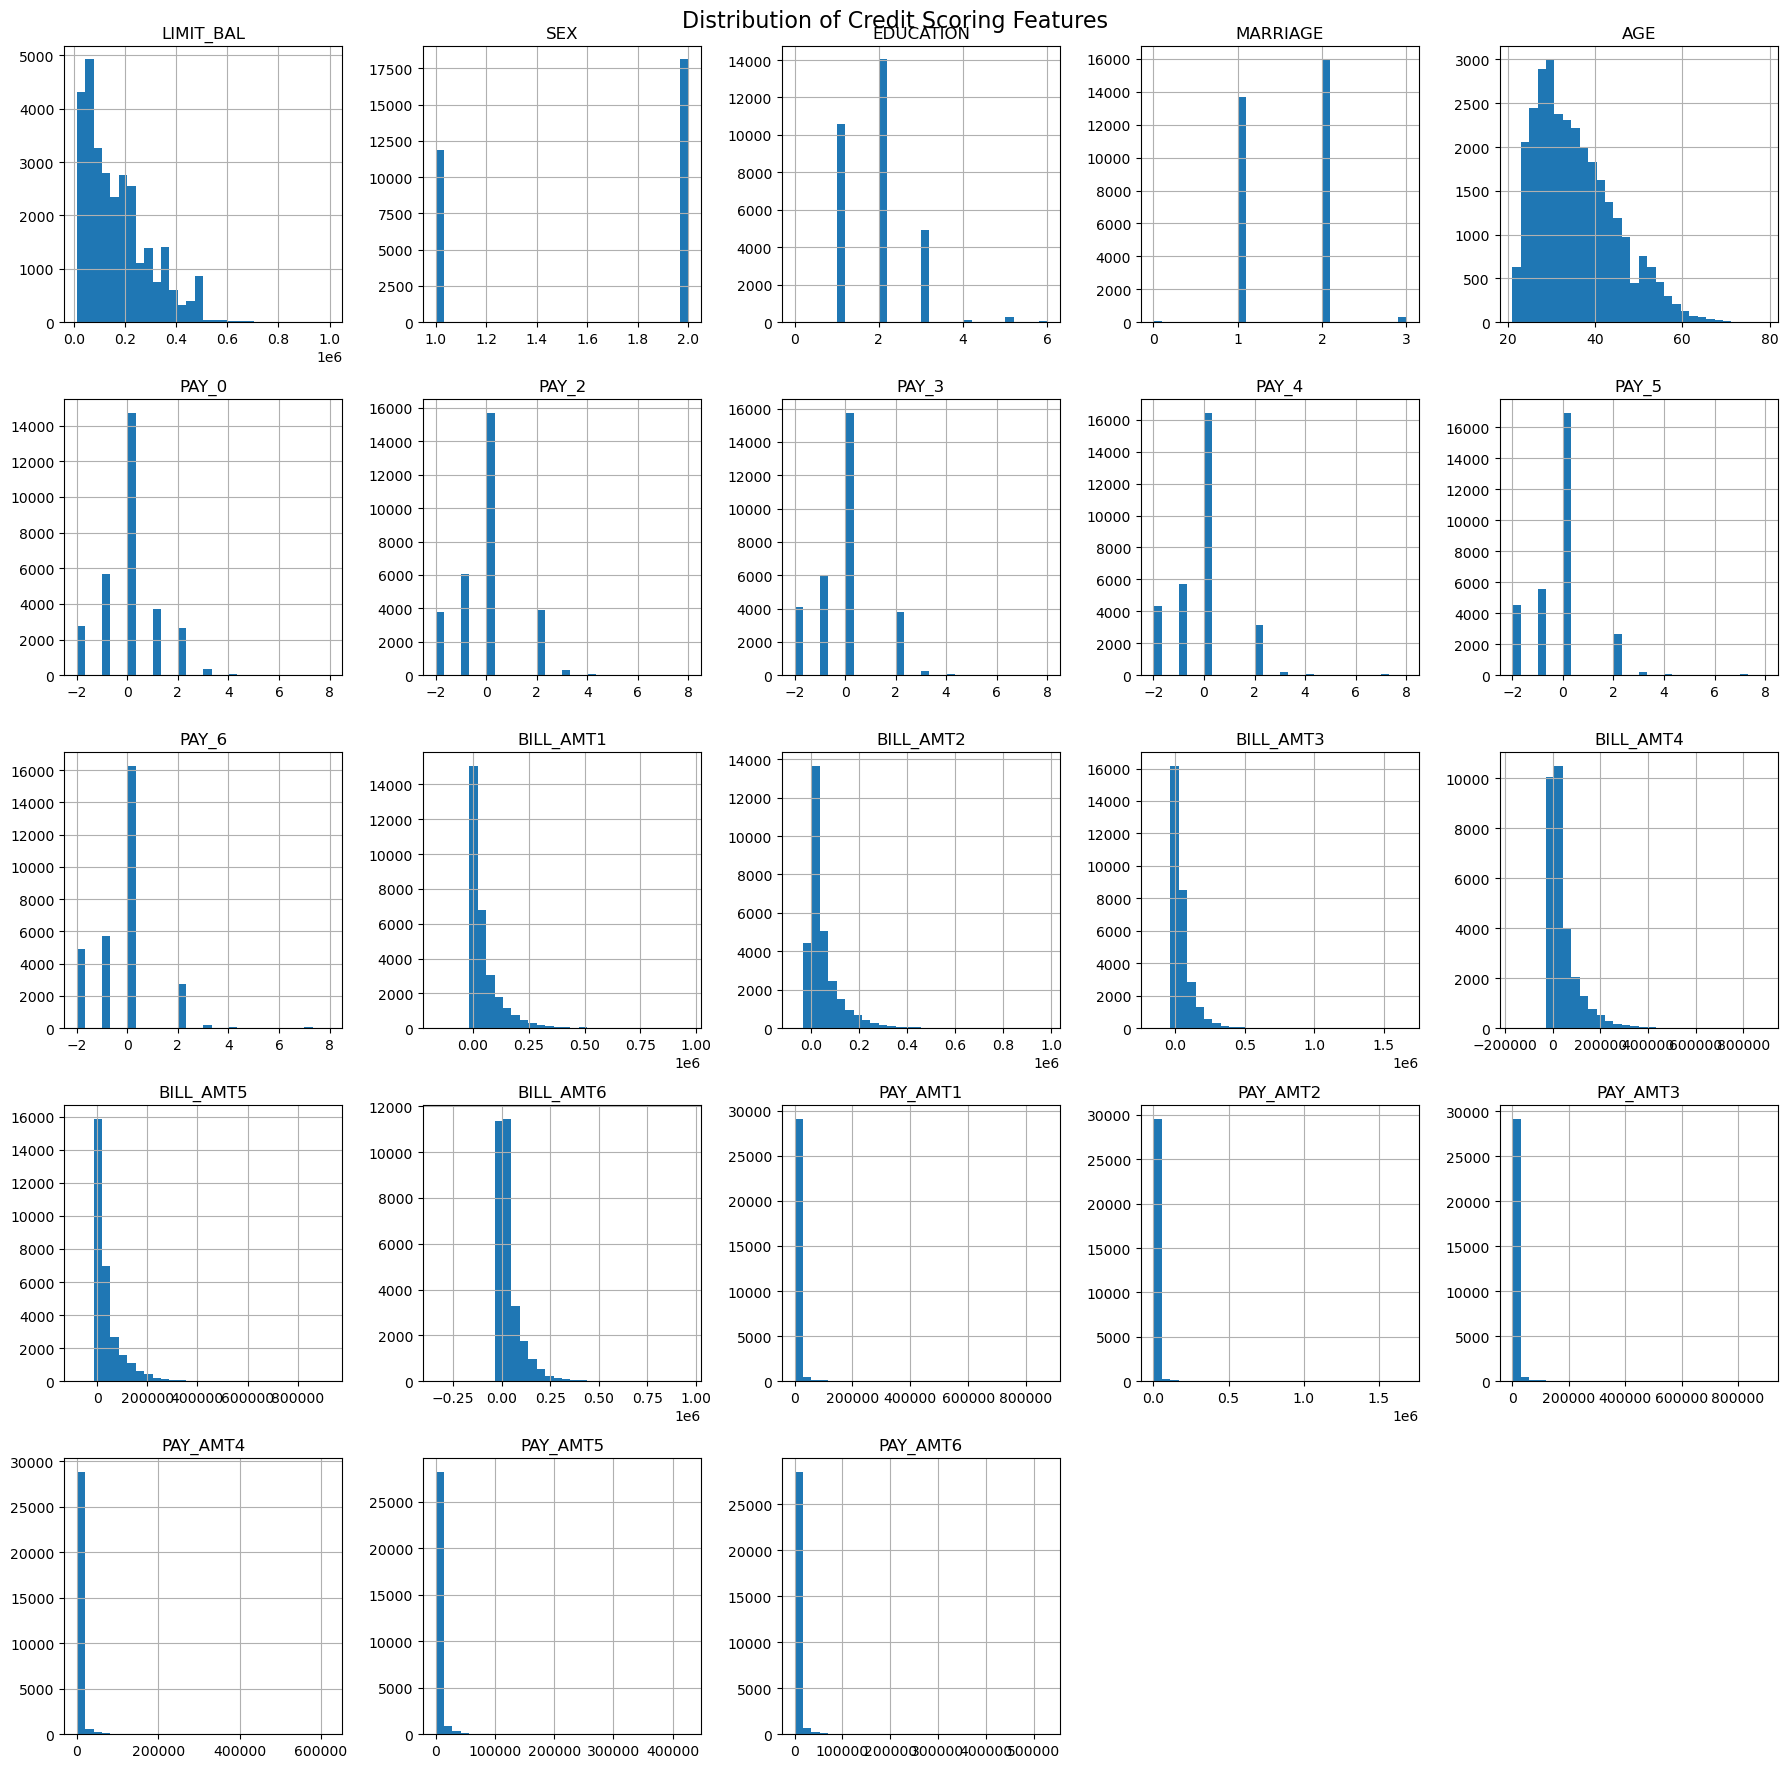

In [14]:
X.hist(
    figsize=(18, 18),
    bins=30
)

plt.suptitle(
    "Distribution of Credit Scoring Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

## 5. Step A - Correlation-Based Feature Selection

The first stage of feature selection examines correlations between predictor variables.

Highly correlated features may contain overlapping or redundant information. Removing selected redundant features can simplify the model while retaining most of the useful predictive information.

A correlation matrix and heatmap are first used to examine relationships among the original **23 predictor features**.

### 5.1 Correlation Heatmap

The correlation matrix measures the linear relationship between pairs of predictor variables.

The heatmap provides a visual representation of these relationships, making highly correlated feature groups easier to identify.

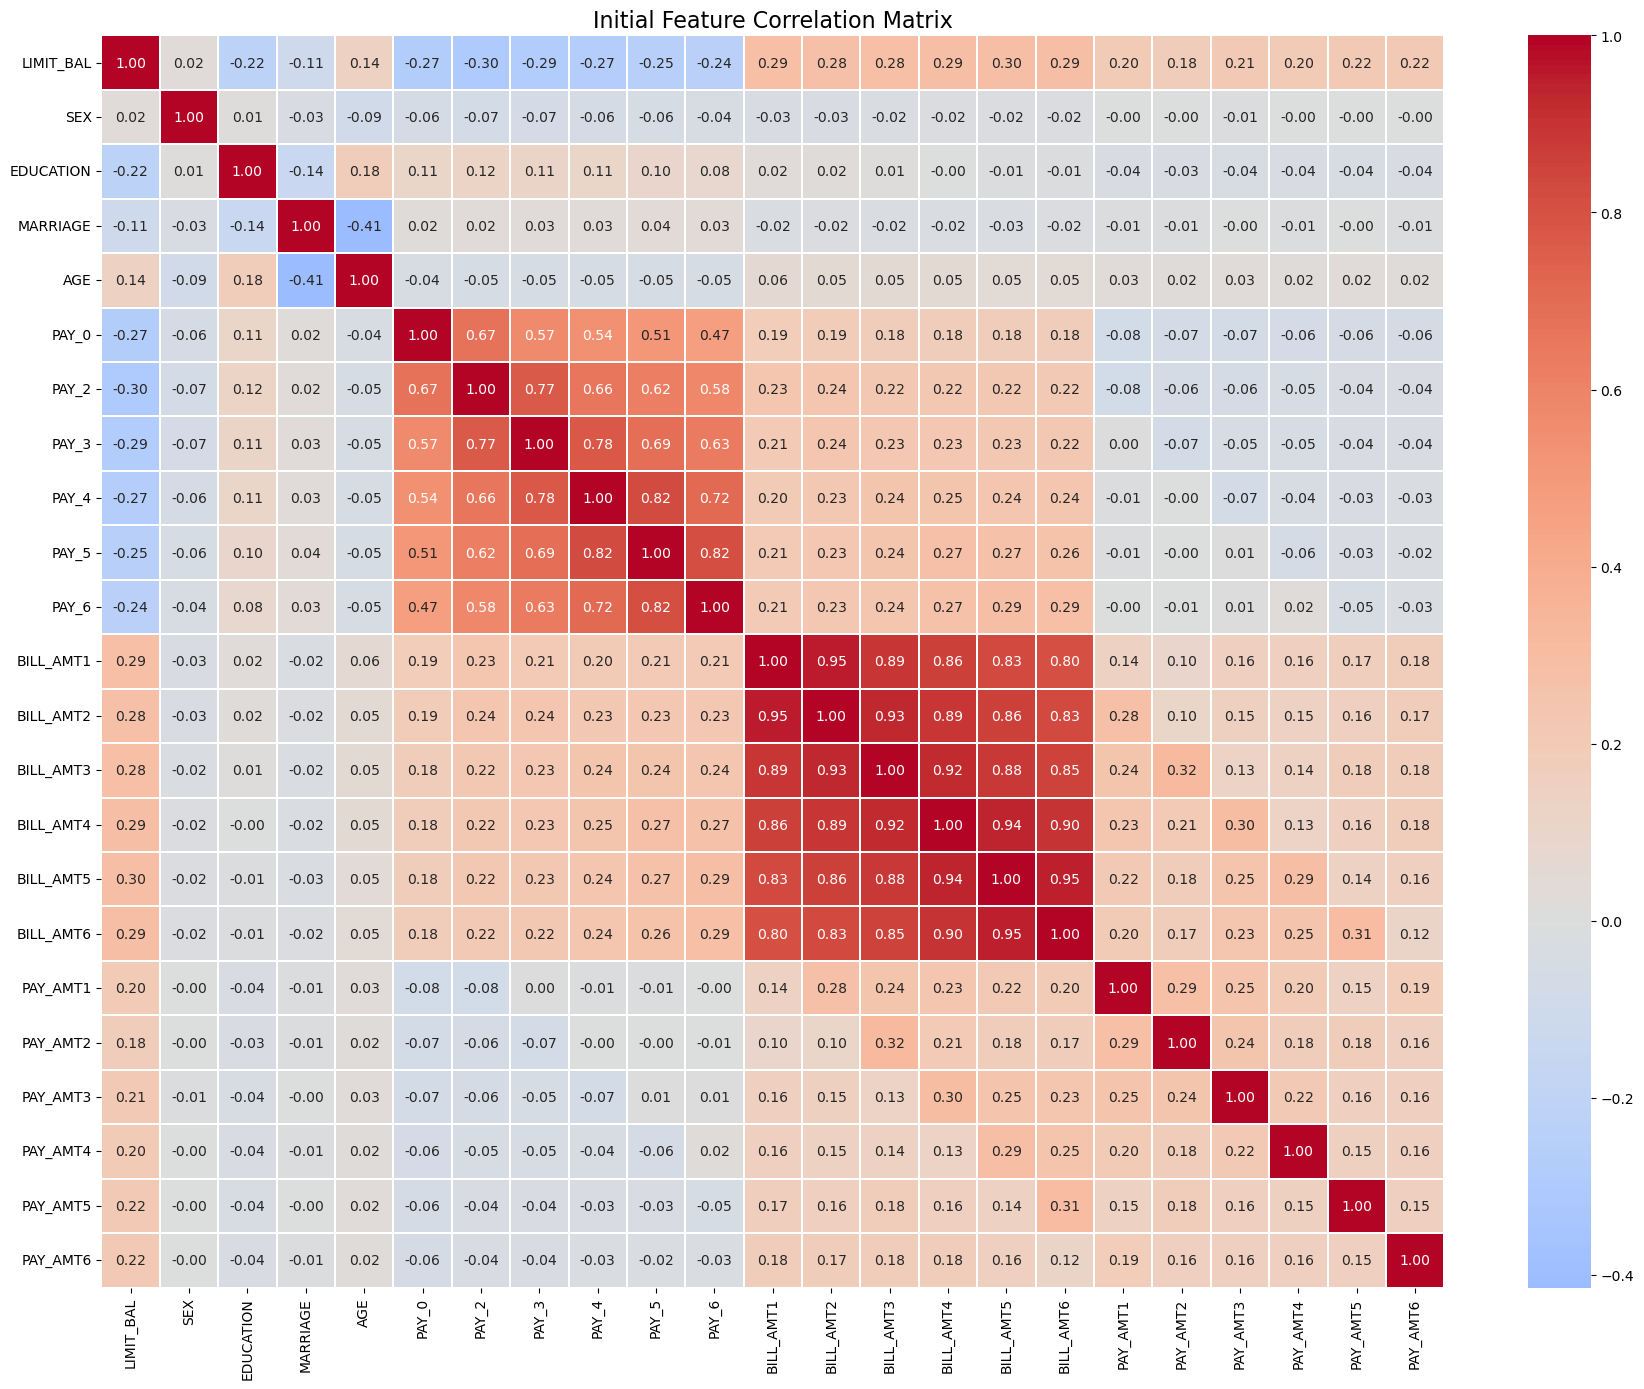

In [18]:
plt.figure(figsize=(18, 14))

sns.heatmap(
    X.corr(),
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.2
)

plt.title(
    "Initial Feature Correlation Matrix",
    fontsize=16
)

plt.tight_layout()
plt.show()

## 6. Train-Test Split

Before feature selection and model evaluation, the dataset is divided into training and testing sets.

A **70% / 30% split** is used:

- **70% → Training data**
- **30% → Testing data**

`stratify=y` is applied to preserve approximately the same default/non-default class distribution in both datasets.

A fixed `random_state` is also used to make the split reproducible.

In [19]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    # Predictor variables
    X,
    # Target Variable
    y,
    # Allocate 30% of the data for testing
    test_size=0.30,
    # Set a random seed for reproducibi
    random_state=RANDOM_STATE,
    # Preserve the class distribution in both training and testing sets
    stratify=y
)

## Checking Split Sizes


In [20]:
print("Full feature set:", X.shape)
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("\nTraining target:", y_train.shape)
print("Testing target:", y_test.shape)

Full feature set: (30000, 23)
Training features: (21000, 23)
Testing features: (9000, 23)

Training target: (21000,)
Testing target: (9000,)


### Observation

The split produces **21,000 training observations** and **9,000 testing observations**, with all 23 original predictor features initially retained.

The training set will be used for feature selection and model development, while the testing set will provide an independent evaluation of model performance.

### 6.1 Tracking Feature-Selection Performance

A results list is initialized to store the number of features, Train AUC, Test AUC, and AUC gap after each feature-selection stage.

This allows the effect of feature reduction on LightGBM performance to be compared systematically.

In [21]:
stage_results = []

### 6.2 Reusable LightGBM Evaluation Function

A reusable evaluation function is created to train the same LightGBM configuration at every feature-selection stage.

Keeping the model configuration consistent allows changes in performance to be attributed primarily to the changing feature set rather than to different model settings.

For each stage, the function calculates:

- **Train ROC-AUC**
- **Test ROC-AUC**
- **AUC Gap**
- **Number of Features**

The AUC gap is calculated as:

**AUC Gap = Train AUC - Test AUC**

A larger gap may indicate greater overfitting, while a smaller gap generally indicates closer performance between the training and unseen testing data.

In [22]:
## Define a reusable function for evaluating LightGBM at different feature selection stages
def evaluate_lightgbm_stage(
    stage_name,
    X_train_stage,
    X_test_stage,
    y_train,
    y_test
):
    
    # Initialize the LightGBM classifier with predefined hyperparameters
    model = LGBMClassifier(
        objective="binary", # Binary classification problem
        n_estimators=300,   # Number of boosting trees
        learning_rate=0.05,  # Learning rate for boosting
        num_leaves=31,       # Maximum number of leaves per tree
        random_state=RANDOM_STATE, # Ensures reproducible results
        n_jobs=-1,          # Use all available CPU cores
        verbosity=-1
    )

    # Train the model
    model.fit(
        X_train_stage,
        y_train
    )

    # Predict default probabilities
    train_probabilities = model.predict_proba(
        X_train_stage
    )[:, 1]
    
     # Predict probabilities for the testing set
    test_probabilities = model.predict_proba(
        X_test_stage
    )[:, 1]

    # Calculate the ROC-AUC for the training set
    train_auc = roc_auc_score(
        y_train,
        train_probabilities
    )
    
    # Calculate the ROC-AUC for the testing set
    test_auc = roc_auc_score(
        y_test,
        test_probabilities
    )
    
    # Calculate the difference between Train AUC and Test AUC
    auc_gap = train_auc - test_auc
    
    # Store the evaluation results in a dictionary
    result = {
        "Stage": stage_name,
        "Number of Features": X_train_stage.shape[1],
        "Train AUC": train_auc,
        "Test AUC": test_auc,
        "AUC Gap": auc_gap
    }

    # Save the results for later comparison
    stage_results.append(result)
    
    # Print the evaluation results
    print("=" * 55)
    print("Stage:", stage_name)
    print("Number of features:", X_train_stage.shape[1])
    print(f"Train AUC: {train_auc:.4f}")
    print(f"Test AUC: {test_auc:.4f}")
    print(f"AUC Gap: {auc_gap:.4f}")
    print("=" * 55)

    # Return the trained model
    return model

## 7.  Baseline LightGBM — All 23 Features

Before removing any features, a baseline **LightGBM classifier** is trained using all **23 predictor features**.

This establishes a reference performance level against which each subsequent feature-selection stage can be compared.

If the number of features can be reduced substantially while maintaining similar Test ROC-AUC, the reduced feature set can be considered more efficient without sacrificing much predictive performance.

In [23]:
# Train and evaluate the baseline LightGBM model using all 23 features
baseline_lgbm = evaluate_lightgbm_stage(
    # Name of the current evaluation stage
    stage_name="Baseline - All Features",
     # Training feature set containing all 23 features
    X_train_stage=X_train,
    # Testing feature set containing all 23 features
    X_test_stage=X_test,
     # Training target labels
    y_train=y_train,
     # Testing target labels
    y_test=y_test
)

Stage: Baseline - All Features
Number of features: 23
Train AUC: 0.9184
Test AUC: 0.7750
AUC Gap: 0.1433


###  Baseline Result

Using all **23 predictor features**, the LightGBM model achieves:

- **Train AUC: 0.9184**
- **Test AUC: 0.7750**
- **AUC Gap: 0.1433**

The Test AUC establishes the initial benchmark for the feature-selection process.

The noticeable difference between Train and Test AUC also suggests that the model fits the training data considerably better than the unseen testing data.

The goal of the following feature-selection stages is therefore to reduce redundant or weak predictors while preserving as much of the baseline Test AUC as possible.

### 7.1 Baseline Predictions

The trained baseline LightGBM model is used to generate the probability of
default for both the training and testing datasets.

`predict_proba()` returns the probability of each class. Since **Default = 1**
is the positive class, `[:, 1]` is used to extract the predicted probability
of default.

These probabilities are used to calculate ROC-AUC and construct the ROC curve.

In [26]:
# Predict the probability of default for the training dataset
baseline_train_probability = (
     # Generate class probabilities using the trained LightGBM model
    baseline_lgbm.predict_proba(
        X_train
    )[:, 1]  # Select the probability of the positive class (Default = 1)
)

# Predict the probability of default for the testing dataset
baseline_test_probability = (
    # Generate class probabilities using the trained LightGBM model
    baseline_lgbm.predict_proba(
        X_test
    )[:, 1]  # Select the probability of the positive class (Default = 1)
)

### 7.2 Baseline ROC Curve

The Receiver Operating Characteristic (**ROC**) curve evaluates the model's
ability to distinguish between default and non-default customers across
different classification thresholds.

The curve plots:

- **True Positive Rate (TPR)** on the y-axis
- **False Positive Rate (FPR)** on the x-axis

The **Area Under the Curve (AUC)** summarizes the model's overall
discriminative ability. A higher AUC indicates better separation between
the two classes.

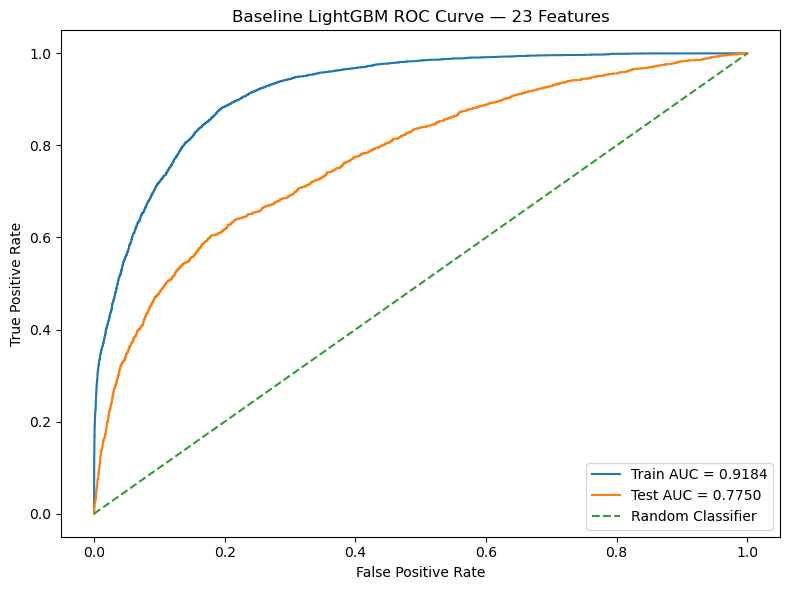

In [27]:
# Calculate the False Positive Rate (FPR) and True Positive Rate (TPR) for the training set
train_fpr, train_tpr, _ = roc_curve(
    y_train, # Actual target values
    baseline_train_probability # Predictes propbabilities
)
# Calculate the False Positive Rate (FPR) and True Positive Rate (TPR) for the testing set
test_fpr, test_tpr, _ = roc_curve(
    y_test,  # Actual target values
    baseline_test_probability  # Predicted probabilities
)
# Calculate the Area Under the ROC Curve (AUC) for the training set
train_auc = roc_auc_score(
    y_train,  # Actual target values
    baseline_train_probability # Predicted probabilities
)
# Calculate the Area Under the ROC Curve (AUC) for the testing set
test_auc = roc_auc_score(
    y_test,  # Actual target values
    baseline_test_probability  # Predicted probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    train_fpr,
    train_tpr,
    label=f"Train AUC = {train_auc:.4f}"
)

plt.plot(
    test_fpr,
    test_tpr,
    label=f"Test AUC = {test_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Baseline LightGBM ROC Curve — 23 Features")
plt.legend()
plt.tight_layout()
plt.show()

###  Observation

The baseline LightGBM model achieves:

- **Train AUC = 0.9184**
- **Test AUC = 0.7750**

The model demonstrates useful discrimination on unseen data, but the difference
between training and testing AUC indicates some degree of overfitting.

This baseline will be used as the reference for evaluating whether feature
selection can reduce model complexity while maintaining similar predictive
performance.

### 7.3 Baseline Results Summary

The baseline evaluation results are converted into a DataFrame to provide
a structured reference for comparison with the upcoming feature-selection
stages.

In [28]:
# Converting the collected evaluation results into a DataFrame
stage_results_df = pd.DataFrame(
    stage_results
)
# Display the results table rounded to four decimal places
display(
    stage_results_df.round(4)
)

,Stage,Number of Features,Train AUC,Test AUC,AUC Gap
0,Baseline - All Features,23,0.9184,0.775,0.1433


###  Observation

The baseline model uses all **23 predictor features** and achieves a
**Test AUC of 0.7750**.

The following feature-selection stages will attempt to reduce the number
of predictors while preserving similar performance on unseen data.

## 8.  Correlation Filtering

The first feature-selection procedure identifies highly correlated predictors
that may contain redundant information.

An absolute Pearson correlation threshold of **0.80** is used.

When two features exceed this threshold, they are not removed automatically.
Instead, their individual predictive ability is compared using ROC-AUC.

The feature with the stronger individual predictive performance is retained,
while the weaker feature is considered for removal.

### 8.1 Training-Set Correlation Matrix

The absolute Pearson correlation matrix is calculated using **only the
training dataset**.

Using the training data for feature-selection decisions helps prevent
information from the test set from influencing the feature-selection process.

In [29]:
## We only use X_train only
corr_matrix = X_train.corr().abs() ## Using .abs() converts all correlation values to postive numbers

# Display the first five rows of the correlation matrix
corr_matrix.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
LIMIT_BAL,1.000000,0.030019,0.213701,0.114321,0.150665,0.268745,0.300524,0.291529,0.270330,0.253687,...,0.284634,0.294917,0.294924,0.290908,0.192822,0.194009,0.210032,0.206549,0.225059,0.217728
SEX,0.030019,1.000000,0.007141,0.031797,0.092993,0.063384,0.071592,0.072490,0.064492,0.057486,...,0.024774,0.020334,0.016801,0.017362,0.000741,0.006204,0.001941,0.000358,0.003239,0.003829
EDUCATION,0.213701,0.007141,1.000000,0.142210,0.168914,0.109288,0.126302,0.118453,0.113763,0.102787,...,0.019772,0.005506,0.003116,0.003707,0.032029,0.026379,0.038094,0.044509,0.036421,0.033139
MARRIAGE,0.114321,0.031797,0.142210,1.000000,0.412734,0.021073,0.028392,0.035035,0.035573,0.036986,...,0.025159,0.023743,0.026559,0.022216,0.009752,0.009655,0.000083,0.010333,0.004612,0.008814
AGE,0.150665,0.092993,0.168914,0.412734,1.000000,0.038690,0.050860,0.050726,0.048490,0.052244,...,0.056552,0.052852,0.051736,0.052343,0.032147,0.028545,0.026337,0.026664,0.030101,0.024031


### 8.2 Correlation Matrix Visualization

The absolute correlation matrix is visualized using a heatmap.

This makes groups of strongly related predictors easier to identify,
particularly among repayment-status variables and monthly bill amounts.

Features with an absolute correlation greater than **0.80** are considered
candidates for further evaluation.

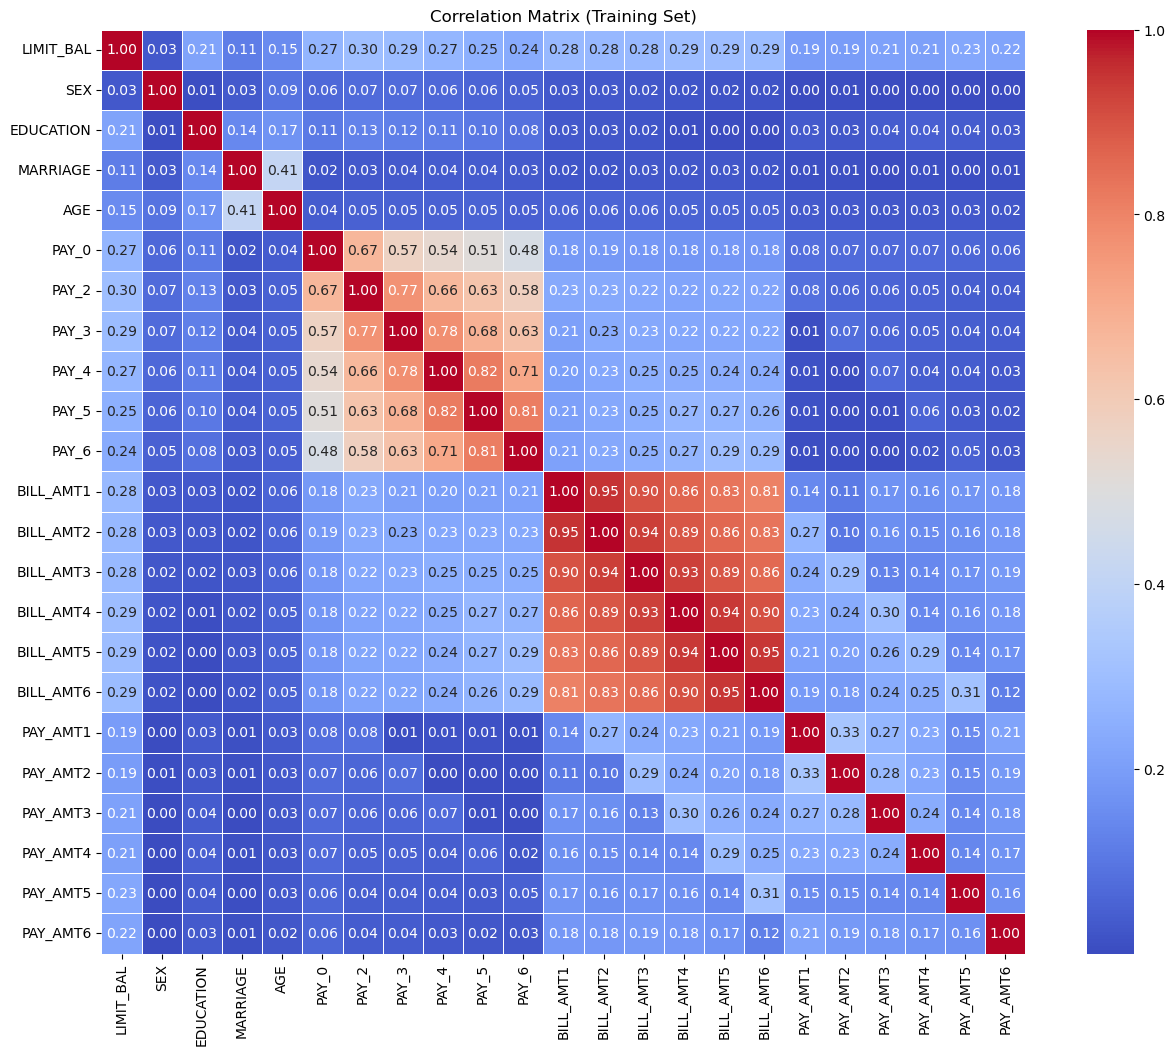

In [30]:
plt.figure(figsize=(16,12))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    square=True,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix (Training Set)")

plt.show()

### 8.3 Upper Triangle of the Correlation Matrix

A correlation matrix is symmetric, meaning that the correlation between
Feature A and Feature B appears twice.

To avoid evaluating the same feature pair more than once, only the
**upper triangle** of the correlation matrix is retained.

The main diagonal is excluded because every feature has a correlation of
1.0 with itself.

In [31]:
# Keep only the upper triangle of the correlation matrix
upper_triangle = corr_matrix.where(
     # Create a mask for the upper triangle of the matrix
    np.triu(
        # Create a matrix of ones with the same shape as the correlation matrix
        np.ones(corr_matrix.shape),
         # Exclude the main diagonal (self-correlation)
        k=1
    ).astype(bool)
)
# Display the first five rows of the upper triangle matrix
upper_triangle.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
LIMIT_BAL,NaN,0.030019,0.213701,0.114321,0.150665,0.268745,0.300524,0.291529,0.270330,0.253687,...,0.284634,0.294917,0.294924,0.290908,0.192822,0.194009,0.210032,0.206549,0.225059,0.217728
SEX,NaN,NaN,0.007141,0.031797,0.092993,0.063384,0.071592,0.072490,0.064492,0.057486,...,0.024774,0.020334,0.016801,0.017362,0.000741,0.006204,0.001941,0.000358,0.003239,0.003829
EDUCATION,NaN,NaN,NaN,0.142210,0.168914,0.109288,0.126302,0.118453,0.113763,0.102787,...,0.019772,0.005506,0.003116,0.003707,0.032029,0.026379,0.038094,0.044509,0.036421,0.033139
MARRIAGE,NaN,NaN,NaN,NaN,0.412734,0.021073,0.028392,0.035035,0.035573,0.036986,...,0.025159,0.023743,0.026559,0.022216,0.009752,0.009655,0.000083,0.010333,0.004612,0.008814
AGE,NaN,NaN,NaN,NaN,NaN,0.038690,0.050860,0.050726,0.048490,0.052244,...,0.056552,0.052852,0.051736,0.052343,0.032147,0.028545,0.026337,0.026664,0.030101,0.024031


### 8.4 Identifying Highly Correlated Feature Pairs

Feature pairs with an absolute Pearson correlation greater than **0.80**
are identified from the upper-triangle matrix.

These pairs are considered potentially redundant because they contain
strongly overlapping information.

At this stage, no features are removed. The predictive strength of the
features in each pair will first be compared.

In [32]:
threshold = 0.80 # Define the correlation threshold

high_corr_pairs = []# Create an empty list to store highly correlated feature pairs

# Loop through every feature (column) in the upper triangle matrix
for col in upper_triangle.columns:
    
   for row in upper_triangle.index: # Loop through every feature (row)
         
        correlation = upper_triangle.loc[row, col] # Get the correlation value between the current feature pair

        if pd.notnull(correlation):   # Ignore empty (NaN) values

            if correlation > threshold: # Check if the correlation exceeds the threshold

                high_corr_pairs.append(# Save the feature pair and its correlation value
                    (row, col, correlation)
                )

high_corr_pairs # Display the list of highly correlated feature pairs

[('PAY_4', 'PAY_5', np.float64(0.8174107317202461)),
 ('PAY_5', 'PAY_6', np.float64(0.8133656344809543)),
 ('BILL_AMT1', 'BILL_AMT2', np.float64(0.9525064610449504)),
 ('BILL_AMT1', 'BILL_AMT3', np.float64(0.9005329783414517)),
 ('BILL_AMT2', 'BILL_AMT3', np.float64(0.9361830787707595)),
 ('BILL_AMT1', 'BILL_AMT4', np.float64(0.8634872804272309)),
 ('BILL_AMT2', 'BILL_AMT4', np.float64(0.8938935572987068)),
 ('BILL_AMT3', 'BILL_AMT4', np.float64(0.9329786981864701)),
 ('BILL_AMT1', 'BILL_AMT5', np.float64(0.8340553413008839)),
 ('BILL_AMT2', 'BILL_AMT5', np.float64(0.8624532718032484)),
 ('BILL_AMT3', 'BILL_AMT5', np.float64(0.8930010108697125)),
 ('BILL_AMT4', 'BILL_AMT5', np.float64(0.9415399755894724)),
 ('BILL_AMT1', 'BILL_AMT6', np.float64(0.8076301121838098)),
 ('BILL_AMT2', 'BILL_AMT6', np.float64(0.8339887098470203)),
 ('BILL_AMT3', 'BILL_AMT6', np.float64(0.8589533577389181)),
 ('BILL_AMT4', 'BILL_AMT6', np.float64(0.9030572801783648)),
 ('BILL_AMT5', 'BILL_AMT6', np.float64(0

###  Observation

Several strongly correlated relationships are present in the dataset.

The strongest relationships occur mainly among the monthly `BILL_AMT`
features. For example, consecutive monthly bill amounts show correlations
above **0.90** in several cases.

Strong correlations are also observed among some repayment-status features.

Rather than removing features solely because of high correlation, their
individual predictive performance will be compared in the next step.

### 8.5 Highly Correlated Feature Pairs

The identified highly correlated feature pairs are converted into a
DataFrame for clearer inspection.

The table displays:

- Feature 1
- Feature 2
- Their absolute correlation coefficient

These pairs will be evaluated using individual ROC-AUC scores before
features are removed.

In [33]:
high_corr_df = pd.DataFrame(
    high_corr_pairs,
    columns=[
        "Feature 1",
        "Feature 2",
        "Correlation"
    ]
)

display(high_corr_df)

,Feature 1,Feature 2,Correlation
0,PAY_4,PAY_5,0.817411
1,PAY_5,PAY_6,0.813366
2,BILL_AMT1,BILL_AMT2,0.952506
3,BILL_AMT1,BILL_AMT3,0.900533
4,BILL_AMT2,BILL_AMT3,0.936183
5,BILL_AMT1,BILL_AMT4,0.863487
6,BILL_AMT2,BILL_AMT4,0.893894
7,BILL_AMT3,BILL_AMT4,0.932979
8,BILL_AMT1,BILL_AMT5,0.834055
9,BILL_AMT2,BILL_AMT5,0.862453


#### These feature pairs are not removed immediately. In the next step, their predictive power is compared using ROC-AUC, and the less informative feature from each highly correlated pair is removed while the more predictive feature is retained.

### 8.6 Single-Feature ROC-AUC Function

A helper function is created to estimate the individual predictive ability
of each feature using ROC-AUC on the training data.

For highly correlated feature pairs, the feature with the higher individual
AUC is considered the stronger predictor.

If the calculated AUC is below 0.50, `1 - AUC` is used so that the score
reflects predictive strength regardless of whether the relationship with
default is positive or negative.

In [34]:
def feature_auc(feature):
    
    # Compute the ROC-AUC score using the feature alone
    score = roc_auc_score(
        y_train,
        X_train[feature]
    )

    # If the relationship is negative, convert it to a positive predictive score

    if score < 0.50:

        score = 1 - score

    return score

### 8.7 Comparing Predictive Strength Within Correlated Pairs

Each highly correlated feature pair is evaluated using the single-feature
ROC-AUC function.

For every pair:

1. The individual AUC of both features is calculated.
2. The feature with the higher AUC is retained.
3. The feature with the lower AUC is marked for removal.

This approach combines **correlation analysis** with **predictive performance**
instead of removing variables based on correlation alone.

In [35]:
drop_features = []  # Create a list to store features that will be removed

comparison_results = [] # Create a list to store comparison results

for feature1, feature2, corr in high_corr_pairs: # Loop through every highly correlated feature pair

    auc1 = feature_auc(feature1) # Calculate the AUC score of the first feature

    auc2 = feature_auc(feature2) # Calculate the AUC score of the second feature

    if auc1 >= auc2: # Keep the feature with the higher AUC

        keep = feature1

        drop = feature2

    else:

        keep = feature2

        drop = feature1

    drop_features.append(drop) # Save the feature to be removed

    comparison_results.append({ # Store the comparison results

        "Feature 1": feature1,

        "Feature 2": feature2,

        "Correlation": corr,

        "AUC Feature 1": auc1,

        "AUC Feature 2": auc2,

        "Keep": keep,

        "Drop": drop

    })

#### This cell compares every highly correlated feature pair based on their individual ROC-AUC scores. For each pair, the feature with the higher AUC is selected as the more informative predictor and is retained, while the feature with the lower AUC is marked for removal.

### 8.8 Correlation Comparison Results

The results are organized into a table containing the correlation,
individual AUC scores, retained feature, and feature marked for removal.

In [36]:
comparison_df = pd.DataFrame(
    comparison_results
)

display(comparison_df)

,Feature 1,Feature 2,Correlation,AUC Feature 1,AUC Feature 2,Keep,Drop
0,PAY_4,PAY_5,0.817411,0.614868,0.602441,PAY_4,PAY_5
1,PAY_5,PAY_6,0.813366,0.602441,0.595009,PAY_5,PAY_6
2,BILL_AMT1,BILL_AMT2,0.952506,0.516635,0.509787,BILL_AMT1,BILL_AMT2
3,BILL_AMT1,BILL_AMT3,0.900533,0.516635,0.507818,BILL_AMT1,BILL_AMT3
4,BILL_AMT2,BILL_AMT3,0.936183,0.509787,0.507818,BILL_AMT2,BILL_AMT3
5,BILL_AMT1,BILL_AMT4,0.863487,0.516635,0.505535,BILL_AMT1,BILL_AMT4
6,BILL_AMT2,BILL_AMT4,0.893894,0.509787,0.505535,BILL_AMT2,BILL_AMT4
7,BILL_AMT3,BILL_AMT4,0.932979,0.507818,0.505535,BILL_AMT3,BILL_AMT4
8,BILL_AMT1,BILL_AMT5,0.834055,0.516635,0.503236,BILL_AMT1,BILL_AMT5
9,BILL_AMT2,BILL_AMT5,0.862453,0.509787,0.503236,BILL_AMT2,BILL_AMT5


###  Observation

The results show that highly correlated features do not necessarily have
identical predictive strength.

The feature with the higher individual ROC-AUC is retained from each pair,
allowing redundancy to be reduced while prioritizing predictive information.

### 8.9 Removing Redundant Features

Features marked for removal during the correlated-pair comparison are
deduplicated and removed from both the training and testing datasets.

Applying the same feature set to both datasets ensures that the model is
trained and evaluated using identical predictor variables.

In [37]:
drop_features = list(set(drop_features)) # Remove duplicate feature names

# Remove the selected features from the training dataset
X_train_corr = X_train.drop(
    columns=drop_features
)

# Remove the same features from the testing dataset
X_test_corr = X_test.drop(
    columns=drop_features
)

# Display the number of features before and after feature removal
print("Original Features :", X_train.shape[1])

print("Removed Features :", len(drop_features))

print("Remaining Features :", X_train_corr.shape[1])

Original Features : 23
Removed Features : 7
Remaining Features : 16


###  Observation

The correlation-filtering stage reduces the feature set from
**23 predictors to 16 predictors**.

This removes **7 redundant features**, producing a more compact feature
set for the next stage of the pipeline.

## 9.  LightGBM After Correlation Filtering

The LightGBM model is retrained using the **16 features** remaining after
correlation filtering.

The same LightGBM configuration used for the baseline model is maintained
so that the performance change can be attributed primarily to feature
selection.

In [38]:
corr_lgbm = evaluate_lightgbm_stage(

    stage_name="After Correlation Filter",

    X_train_stage=X_train_corr,

    X_test_stage=X_test_corr,

    y_train=y_train,

    y_test=y_test

)

Stage: After Correlation Filter
Number of features: 16
Train AUC: 0.9118
Test AUC: 0.7751
AUC Gap: 0.1367


###  Correlation Filter Result

After correlation filtering, the LightGBM model achieves:

- **Number of Features: 16**
- **Train AUC: 0.9118**
- **Test AUC: 0.7751**
- **AUC Gap: 0.1367**

Compared with the baseline, the feature count decreased from **23 to 16**
while Test AUC remained essentially unchanged:

**0.7750 → 0.7751**

The Train-Test AUC gap also decreased from **0.1433 to 0.1367**.

This indicates that the correlation filter successfully removed redundant
features without reducing predictive performance on the test set.

## Current Results

In [39]:
stage_results_df = pd.DataFrame(
    stage_results
)

display(
    stage_results_df.round(4)
)

,Stage,Number of Features,Train AUC,Test AUC,AUC Gap
0,Baseline - All Features,23,0.9184,0.7750,0.1433
1,After Correlation Filter,16,0.9118,0.7751,0.1367


### 9.1 ROC Curve After Correlation Filtering

The ROC curve of the correlation-filtered LightGBM model is compared with
the baseline model to evaluate whether removing highly correlated features
affected the model's ability to distinguish between default and non-default
customers.

The comparison includes:

- **Baseline LightGBM:** 23 features
- **Correlation-Filtered LightGBM:** 16 features
- **Random Classifier:** reference diagonal

If the ROC curves remain close after feature reduction, it indicates that
the removed features contained mostly redundant information rather than
unique predictive information.

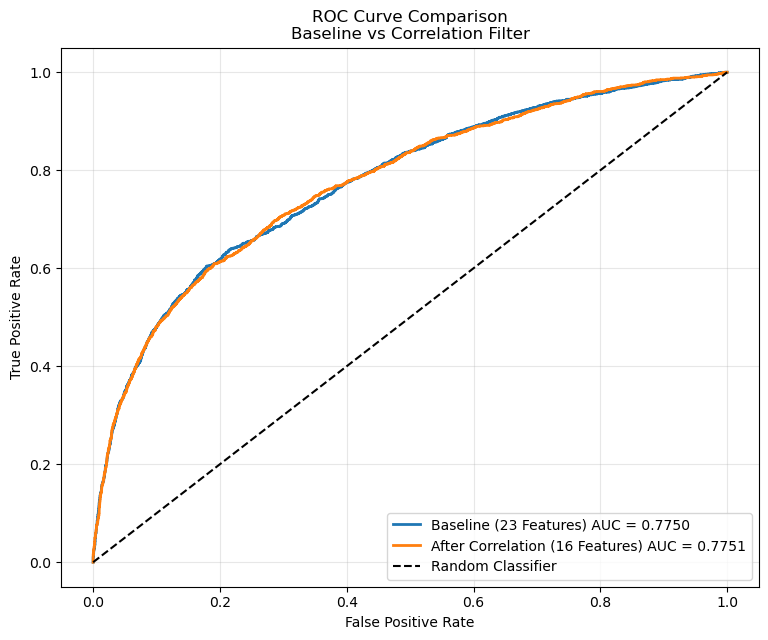

In [40]:
# Predicted probabilities
corr_train_probability = corr_lgbm.predict_proba(X_train_corr)[:, 1]
corr_test_probability = corr_lgbm.predict_proba(X_test_corr)[:, 1]

# ROC coordinates
corr_train_fpr, corr_train_tpr, _ = roc_curve(
    y_train,
    corr_train_probability
)

corr_test_fpr, corr_test_tpr, _ = roc_curve(
    y_test,
    corr_test_probability
)

# AUC
corr_train_auc = roc_auc_score(
    y_train,
    corr_train_probability
)

corr_test_auc = roc_auc_score(
    y_test,
    corr_test_probability
)

# Plot
plt.figure(figsize=(9,7))

# Baseline
plt.plot(
    test_fpr,
    test_tpr,
    label=f'Baseline (23 Features) AUC = {test_auc:.4f}',
    linewidth=2
)

# Correlation Filter
plt.plot(
    corr_test_fpr,
    corr_test_tpr,
    label=f'After Correlation (16 Features) AUC = {corr_test_auc:.4f}',
    linewidth=2
)

# Random classifier
plt.plot(
    [0,1],
    [0,1],
    'k--',
    label='Random Classifier'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison\nBaseline vs Correlation Filter")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

###  Observation

The ROC curves of the baseline and correlation-filtered models are nearly
identical.

The baseline model using **23 features** achieves a Test AUC of **0.7750**,
while the correlation-filtered model using only **16 features** achieves a
Test AUC of **0.7751**.

This means that removing **7 highly correlated and redundant features**
did not reduce the model's predictive performance.

In fact, the Test AUC increased slightly by **0.0001**, although this
difference is negligible.

The result suggests that the correlation-filtered feature set is more compact
while retaining essentially the same discriminative ability as the original
23-feature model.

## 10.  Step B - Information Value (IV) Feature Selection

The second stage of the feature-selection pipeline uses **Information Value (IV)**
to evaluate the predictive strength of the features remaining after correlation
filtering.

Information Value is commonly used in credit-scoring problems to measure how
well a feature separates **default** and **non-default** customers.

The calculation involves:

1. Dividing feature values into bins.
2. Calculating the distribution of default and non-default customers.
3. Computing the **Weight of Evidence (WoE)** for each bin.
4. Calculating and summing the **Information Value (IV)** across the bins.

According to the selection criterion used in this project, features with:

**IV ≤ 0.0**

are removed from the feature set.

### 10.1 Preparing the Training Data for IV Calculation

Information Value requires the predictor variables and target variable to be
available within the same DataFrame.

Therefore, the correlation-filtered training features are copied and the
target variable `Y` is added.

Only the **training data** is used for IV calculation so that information from
the test set does not influence the feature-selection process.

In [41]:
# Create a copy of the training features
train_iv = X_train_corr.copy()
# Add the target variable to the training DataFrame
train_iv["Y"] = y_train.values

### 10.2 Information Value Calculation Function

A reusable function is created to calculate the **Information Value (IV)**
of an individual feature.

For numerical variables, `pd.qcut()` divides the observations into
approximately equal-frequency bins.

For each bin, the function calculates:

- Number of default customers (**Bad**)
- Number of non-default customers (**Good**)
- Distribution of Bad customers
- Distribution of Good customers
- Weight of Evidence (**WoE**)
- Information Value (**IV**)

Weight of Evidence is calculated as:

**WoE = ln(Good Distribution / Bad Distribution)**

Information Value is then calculated as:

**IV = the sum of (Good Distribution − Bad Distribution) × WoE**

Small replacement values are used when a distribution equals zero to avoid
division-by-zero errors.

In [52]:
# Define a function to calculate the Information Value (IV) of a feature
def calculate_iv(data, feature, target, bins=10):

    # Select only the feature and target columns
    df = data[[feature, target]].copy()

    # Bins are intervals created by dividing continuous data into
    # equal-frequency groups. These bins are used to calculate
    # Weight of Evidence (WoE) and Information Value (IV).

    # If the feature is numerical, divide it into equal-frequency bins
    if pd.api.types.is_numeric_dtype(df[feature]):

        df["bin"] = pd.qcut(
            df[feature],
            q=bins,
            duplicates="drop"
        )

    # If the feature is categorical, use its original categories
    else:

        df["bin"] = df[feature]

    # Count the total observations and the number of defaults in each bin
    grouped = (
        df
        .groupby("bin")[target]
        .agg(["count", "sum"])
    )

    # Rename the columns
    grouped.columns = [
        "Total",
        "Bad"
    ]

    # Calculate the number of non-default customers
    grouped["Good"] = (
        grouped["Total"] -
        grouped["Bad"]
    )

    # Calculate the distribution of default customers
    grouped["Bad Distribution"] = (
        grouped["Bad"] /
        grouped["Bad"].sum()
    )

    # Calculate the distribution of non-default customers
    grouped["Good Distribution"] = (
        grouped["Good"] /
        grouped["Good"].sum()
    )

    # Replace zero values to avoid division by zero
    grouped["Bad Distribution"] = grouped[
        "Bad Distribution"
    ].replace(0, 0.0001)

    grouped["Good Distribution"] = grouped[
        "Good Distribution"
    ].replace(0, 0.0001)

    # Calculate the Weight of Evidence (WoE)
    grouped["WoE"] = np.log(

        grouped["Good Distribution"] /

        grouped["Bad Distribution"]

    )

    # Calculate the Information Value (IV)
    grouped["IV"] = (

        grouped["Good Distribution"]

        -

        grouped["Bad Distribution"]

    ) * grouped["WoE"]

    # Sum the IV values across all bins
    iv = grouped["IV"].sum()

    # Return the Information Value
    return iv

### 10.3 Calculating IV for Every Remaining Feature

The Information Value function is applied to every feature remaining after
correlation filtering.

Each feature receives an IV score representing its ability to distinguish
between default and non-default customers.

The scores are stored and ranked from highest to lowest to identify the most
informative predictors.

In [53]:
iv_results = [] # Create an empty list to store the IV results

for feature in X_train_corr.columns: # Loop through every feature in the training dataset

    # Calculate the Information Value of the current feature
    iv = calculate_iv(

        train_iv,

        feature,

        "Y"

    )
    
    # Store the feature name and its IV score
    iv_results.append({

        "Feature": feature,

        "IV": iv

    })

### 10.4 Information Value Ranking

The calculated IV scores are organized into a table and sorted from highest
to lowest.

Features with larger IV values provide stronger separation between default
and non-default customers under the IV calculation used in this project.

In [54]:
iv_table = pd.DataFrame(iv_results)

iv_table = iv_table.sort_values(

    by="IV",

    ascending=False

)

display(iv_table)

,Feature,IV
5,PAY_0,0.887827
6,PAY_2,0.553848
7,PAY_3,0.420040
8,PAY_4,0.368560
0,LIMIT_BAL,0.196724
10,PAY_AMT1,0.160624
11,PAY_AMT2,0.149915
12,PAY_AMT3,0.125689
15,PAY_AMT6,0.090954
13,PAY_AMT4,0.084883


###  Observation

The IV ranking shows that repayment-status variables provide some of the
strongest predictive information for customer default.

`SEX` receives an **IV score of 0.0000**, making it the only remaining feature
that fails the project's selection criterion.

Therefore, `SEX` will be removed before the next model evaluation.

## Interpretation

In [55]:
def iv_strength(iv):

    if iv <= 0:

        return "Remove"

    elif iv < 0.02:

        return "Useless"

    elif iv < 0.10:

        return "Weak"

    elif iv < 0.30:

        return "Medium"

    elif iv < 0.50:

        return "Strong"

    else:

        return "Very Strong"

In [56]:
# Apply the IV interpretation function to every IV score
iv_table["Interpretation"] = (

    iv_table["IV"]

    .apply(iv_strength)

)
# Display the updated IV table with interpretation labels
display(iv_table)

,Feature,IV,Interpretation
5,PAY_0,0.887827,Very Strong
6,PAY_2,0.553848,Very Strong
7,PAY_3,0.420040,Strong
8,PAY_4,0.368560,Strong
0,LIMIT_BAL,0.196724,Medium
10,PAY_AMT1,0.160624,Medium
11,PAY_AMT2,0.149915,Medium
12,PAY_AMT3,0.125689,Medium
15,PAY_AMT6,0.090954,Weak
13,PAY_AMT4,0.084883,Weak


### The table shows that the repayment history variables from pay_0 to pay_4 are the most informative predictors of customer default, while SEX contributes no predicitve info and is going to be removed according to IV<=0.0

### 10.5 Selecting Features Based on Information Value

Features with an Information Value greater than zero are retained.

The selection rule used in this project is:

**Keep feature if IV > 0**

This removes variables that provide no predictive separation according to the
calculated Information Value.

In [57]:
# Select only the features with IV greater than zero
selected_iv = iv_table[

    iv_table["IV"] > 0

]["Feature"].tolist()

# Display the selected features
print(selected_iv)

['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'LIMIT_BAL', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT6', 'PAY_AMT4', 'PAY_AMT5', 'EDUCATION', 'AGE', 'BILL_AMT1', 'MARRIAGE']


###  Observation

A total of **15 features** satisfy the IV selection criterion.

`SEX` is removed because its IV score is **0.0000**, indicating no predictive
separation under the IV calculation used in this project.

The remaining 15 features are retained for the next stage.

### 10.6 Creating the IV-Filtered Datasets

New training and testing datasets are created using only the features that
passed the Information Value filter.

The same selected feature list is applied to both datasets to maintain
consistent model inputs.

In [58]:
# Keep only the selected IV features in the training set

X_train_iv = X_train_corr[
    selected_iv
]

# Keep the same features in the testing set
X_test_iv = X_test_corr[
    selected_iv
]

# Display the number of features before and after IV filtering
print("Features after Correlation:",

      X_train_corr.shape[1])

print("Features after IV:",

      X_train_iv.shape[1])

Features after Correlation: 16
Features after IV: 15


###  Observation

The Information Value stage reduces the feature set from:

**16 features → 15 features**

Only **one additional feature** is removed during this stage.

The complete feature-selection pipeline has now reduced the original
**23 predictors to 15 predictors** before SHAP analysis.

## 11. LightGBM After Information Value Filtering

The LightGBM classifier is retrained using the **15 features** retained after
Information Value filtering.

The same evaluation function and model configuration are used so that the
results can be directly compared with the baseline and correlation-filtered
models.

In [59]:
iv_model = evaluate_lightgbm_stage(

    stage_name="After IV",

    X_train_stage=X_train_iv,

    X_test_stage=X_test_iv,

    y_train=y_train,

    y_test=y_test

)

Stage: After IV
Number of features: 15
Train AUC: 0.9120
Test AUC: 0.7723
AUC Gap: 0.1397


### Information Value Result

After Information Value filtering, LightGBM achieves:

- **Number of Features: 15**
- **Train AUC: 0.9120**
- **Test AUC: 0.7723**
- **AUC Gap: 0.1397**

Compared with the correlation-filtered model, Test AUC decreases slightly:

**0.7751 → 0.7723**

This is a reduction of only **0.0028**, despite reducing the feature set to
15 predictors.

The result indicates that the additional feature removal had only a minor
effect on predictive performance.

### 11.1 Feature-Selection Results So Far

The performance of LightGBM across the first three stages is summarized to
evaluate the trade-off between feature reduction and predictive performance.

In [60]:
stage_results_df = pd.DataFrame(

    stage_results

)

display(stage_results_df.round(4))

,Stage,Number of Features,Train AUC,Test AUC,AUC Gap
0,Baseline - All Features,23,0.9184,0.7750,0.1433
1,After Correlation Filter,16,0.9118,0.7751,0.1367
2,After IV,15,0.9120,0.7723,0.1397


###  Observation

The feature-selection process has reduced the predictor set substantially
while preserving most of the model's performance.

|   Stage    | Features | Train AUC | Test AUC | AUC Gap |
|    ---     |      ---:|---:       |---:      |---:     |
| Baseline   |     23   |  0.9184   | 0.7750   | 0.1433  |
| Correlation Filter| 16 | 0.9118   | 0.7751   | 0.1367  |
| Information Value | 15 | 0.9120   | 0.7723   | 0.1397  |

From the original baseline to the IV-filtered model:

- **8 features have been removed**
- Feature count decreased from **23 to 15**
- Test AUC changed from **0.7750 to 0.7723**
- The absolute Test AUC reduction is only **0.0027**

This suggests that a substantially smaller feature set can retain nearly the
same predictive performance.

## IV Bar Chart

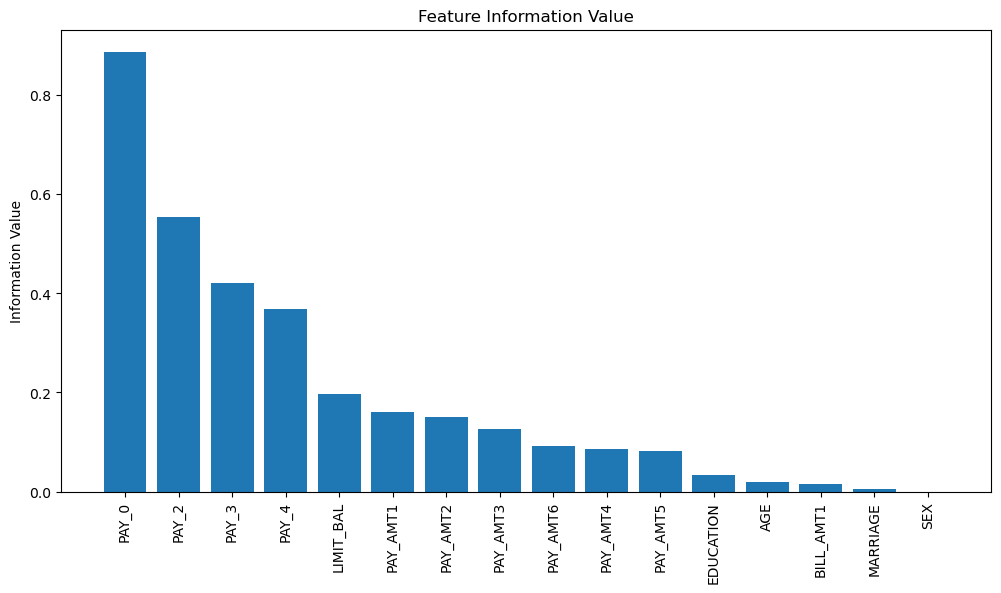

In [62]:
plt.figure(figsize=(12,6))

plt.bar(

    iv_table["Feature"],

    iv_table["IV"]

)

plt.xticks(rotation=90)

plt.ylabel("Information Value")

plt.title("Feature Information Value")

plt.show()

### 11.2 ROC Curve Comparison Across Feature-Selection Stages

The ROC curves of the baseline, correlation-filtered, and IV-filtered
LightGBM models are compared.

This visualization shows whether reducing the number of features materially
changes the model's ability to distinguish between default and non-default
customers.

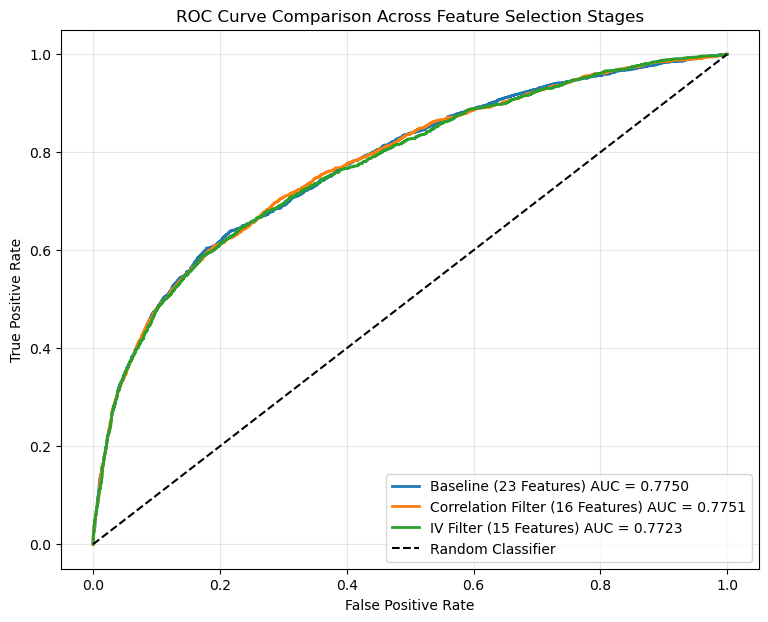

In [63]:
# ROC Curve After IV Filter

# Predict probabilities
iv_train_probability = iv_model.predict_proba(X_train_iv)[:, 1]
iv_test_probability = iv_model.predict_proba(X_test_iv)[:, 1]

# ROC coordinates
iv_train_fpr, iv_train_tpr, _ = roc_curve(
    y_train,
    iv_train_probability
)

iv_test_fpr, iv_test_tpr, _ = roc_curve(
    y_test,
    iv_test_probability
)

# AUC
iv_train_auc = roc_auc_score(
    y_train,
    iv_train_probability
)

iv_test_auc = roc_auc_score(
    y_test,
    iv_test_probability
)

# Compare All Three Stages


plt.figure(figsize=(9,7))

# Baseline
plt.plot(
    test_fpr,
    test_tpr,
    linewidth=2,
    label=f'Baseline (23 Features) AUC = {test_auc:.4f}'
)

# Correlation Filter
plt.plot(
    corr_test_fpr,
    corr_test_tpr,
    linewidth=2,
    label=f'Correlation Filter (16 Features) AUC = {corr_test_auc:.4f}'
)

# IV Filter
plt.plot(
    iv_test_fpr,
    iv_test_tpr,
    linewidth=2,
    label=f'IV Filter (15 Features) AUC = {iv_test_auc:.4f}'
)

# Random classifier
plt.plot(
    [0,1],
    [0,1],
    'k--',
    label='Random Classifier'
)

plt.title("ROC Curve Comparison Across Feature Selection Stages")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

###  Observation

The three ROC curves are very close to one another.

This indicates that reducing the feature set from **23 to 15 predictors**
has only a minor effect on the model's discriminative performance.

The correlation-filtered model produces the highest Test AUC at **0.7751**,
while the IV-filtered model achieves **0.7723**.

Overall, substantial feature reduction was achieved without a major loss in
predictive performance.

## 12.  Step C — SHAP Feature Selection

The final stage of the feature-selection pipeline uses **SHAP
(SHapley Additive exPlanations)** to evaluate the contribution of each
remaining feature to the LightGBM model's predictions.

After Information Value filtering, **15 features** remain.

A LightGBM model is trained using these features, and SHAP values are
calculated to measure their contribution to the model's predictions.

The features are then ranked using their **mean absolute SHAP values**.

A higher mean absolute SHAP value indicates that a feature has a greater
overall influence on the model's predictions.

### 12.1 Training LightGBM Using the IV-Selected Features

A new LightGBM classifier is trained using the **15 features** retained after
Information Value filtering.

This model serves as the basis for SHAP analysis. SHAP will examine how
strongly each of these features contributes to the model's predictions.

In [64]:
# Initialize the LightGBM classifier
shap_model = LGBMClassifier(
    objective="binary",
    random_state=42,
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    verbosity=-1
)
# Train the model using the IV-selected features
shap_model.fit(
    X_train_iv,
    y_train
)

,learning_rate,0.05
,n_estimators,300
,objective,'binary'
,random_state,42
,verbosity,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,subsample_for_bin,200000
,class_weight,None
,min_split_gain,0.0


#### The output tells us that the LightGBM model has been successfully trained using the 15 features selected after the Information Value filter.

### 12.2 Creating the SHAP Explainer

A **SHAP TreeExplainer** is created for the trained LightGBM model.

`TreeExplainer` is designed for tree-based machine learning models and is
used here to explain how the model's features contribute to its predictions.

In [65]:
explainer = shap.TreeExplainer(shap_model) # Create a SHAP explainer for the trained LightGBM model

### 12.3 Calculating SHAP Values

SHAP values are calculated for every observation in the training dataset.

Each SHAP value represents the contribution of a particular feature to the
model's prediction for a particular observation.

The resulting SHAP values will be used to determine the overall importance
of each feature.

In [66]:
shap_values = explainer.shap_values(X_train_iv)

#### The upper cell computes the SHAP values for every feature in every training observation.
#### Each SHAP value indicates how much a feature increases or decreases the predicted probability of customer default.

In [67]:
type(shap_values)

numpy.ndarray

In [68]:
shap_array = shap_values

### 12.4 Calculating Mean Absolute SHAP Importance

To measure the overall importance of each feature, the absolute SHAP values
are averaged across all training observations.

The **mean absolute SHAP value** represents the average magnitude of a
feature's contribution to the model's predictions.

Features with larger mean absolute SHAP values have a greater overall
influence on the LightGBM model.

In [69]:
# Create a DataFrame containing SHAP feature importance
shap_importance = pd.DataFrame({
    
    # Feature names
    "Feature": X_train_iv.columns,
     
    # Mean absolute SHAP values
    "Mean_SHAP":

        np.abs(shap_array).mean(axis=0)

})

# Sort features from most important to least important
shap_importance = shap_importance.sort_values(

    by="Mean_SHAP",

    ascending=False

).reset_index(drop=True)

display(shap_importance)

,Feature,Mean_SHAP
0,PAY_0,0.502355
1,LIMIT_BAL,0.229001
2,BILL_AMT1,0.192213
3,PAY_AMT2,0.127056
4,PAY_AMT1,0.117217
5,PAY_4,0.110130
6,PAY_AMT4,0.101289
7,PAY_AMT3,0.100362
8,PAY_2,0.099193
9,PAY_3,0.092886


### SHAP Importance Results

The SHAP ranking shows that **`PAY_0`** is the most influential feature in
the LightGBM model, with a mean absolute SHAP value of approximately **0.5024**.

The next most influential features are:

1. `LIMIT_BAL` - **0.2290**
2. `BILL_AMT1` - **0.1922**
3. `PAY_AMT2` - **0.1271**
4. `PAY_AMT1` - **0.1172**

This indicates that the customer's most recent repayment status (`PAY_0`)
has the strongest overall influence on the model's predictions among the
15 remaining features.

The SHAP ranking provides an interpretable view of which variables the
LightGBM model relies on most heavily when predicting credit default.

### 12.5 SHAP Feature Importance Plot

A SHAP summary bar plot is used to visualize the global importance of the
15 remaining features.

The features are ordered according to their mean absolute SHAP values.

Longer bars indicate features with a greater average influence on the
LightGBM model's predictions.

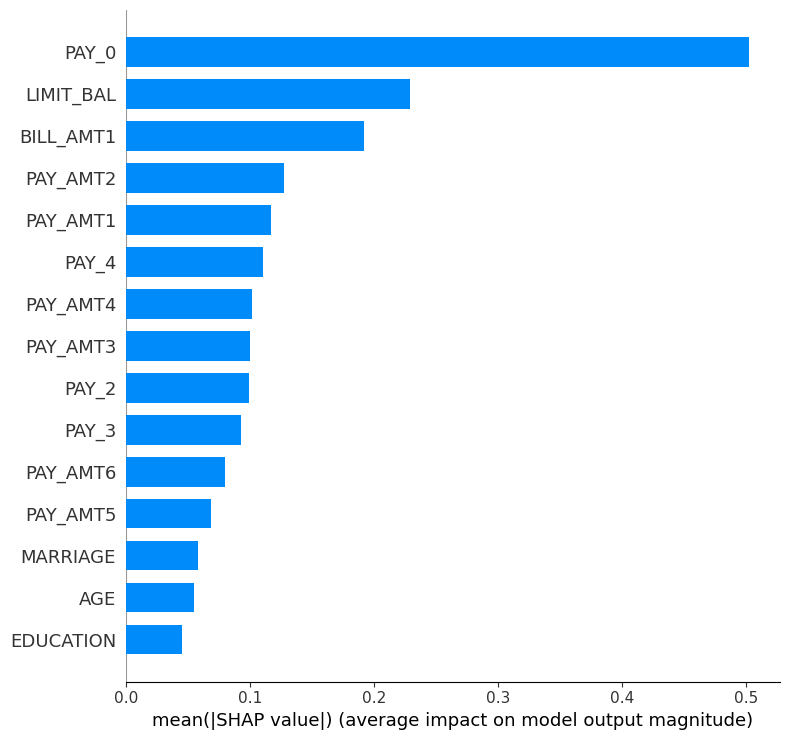

In [70]:
shap.summary_plot(

    shap_array,

    X_train_iv,

    plot_type="bar"

)

###  Observation

The SHAP feature-importance plot confirms the ranking obtained from the
mean absolute SHAP values.

`PAY_0` is clearly the dominant predictor, followed by `LIMIT_BAL` and
`BILL_AMT1`.

The visualization also shows that the model's predictive information is
not distributed equally across the 15 features; some variables contribute
substantially more to the model than others.

### 12.6 Selecting the Top 15 SHAP Features

The features are ranked according to their mean absolute SHAP values, and
the **top 15 features** are selected for the final feature set.

Since the Information Value stage had already reduced the dataset to exactly
15 features, SHAP does not remove any additional variables in this project.

Instead, SHAP provides an importance-based ranking of the final 15 features,
showing which predictors contribute most strongly to the LightGBM model.

In [71]:
TOP_FEATURES = 15

selected_features = shap_importance.head(
    TOP_FEATURES
)["Feature"].tolist()

selected_features_df = pd.DataFrame({
    "Rank": range(1, len(selected_features) + 1),
    "Selected Feature": selected_features
})

display(selected_features_df)

,Rank,Selected Feature
0,1,PAY_0
1,2,LIMIT_BAL
2,3,BILL_AMT1
3,4,PAY_AMT2
4,5,PAY_AMT1
5,6,PAY_4
6,7,PAY_AMT4
7,8,PAY_AMT3
8,9,PAY_2
9,10,PAY_3


###  Final Selected Features

SHAP ranks the final **15 predictor features** from most to least influential.

Because exactly 15 features remained after Information Value filtering, all
15 are retained for the final model.

The feature-selection pipeline has therefore reduced the original feature
set from:

**23 original features → 16 after correlation filtering → 15 after IV → 15 after SHAP ranking**

Although SHAP does not further reduce the number of features, it provides
model-based explainability and establishes the relative importance of the
final predictors.

## 13. Final Selected Feature Set

The final training and testing datasets are created using the 15 features
ranked by SHAP.

The same feature set is applied to both datasets to ensure consistency
between model training and evaluation.

In [72]:
X_train_final = X_train_iv[
    selected_features
]

X_test_final = X_test_iv[
    selected_features
]

print("="*20)
print("Final Features:", X_train_final.shape[1])
print("="*20)

Final Features: 15


###  Observation

The final dataset contains **15 predictor features**.

Compared with the original 23 predictors, the sequential feature-selection
pipeline has removed **8 features**, representing a reduction of approximately
**34.8%** in the number of predictors.

### 13.1 Final LightGBM Evaluation

LightGBM is evaluated once more using the final **15-feature dataset**.

The same evaluation procedure is used to compare the final model with the
previous feature-selection stages.

In [73]:
final_lgbm = evaluate_lightgbm_stage(

    stage_name="Final 15 Features",

    X_train_stage=X_train_final,

    X_test_stage=X_test_final,

    y_train=y_train,

    y_test=y_test

)

Stage: Final 15 Features
Number of features: 15
Train AUC: 0.9120
Test AUC: 0.7723
AUC Gap: 0.1397


###  Final Feature-Selection Result

The final 15-feature LightGBM model achieves:

- **Train AUC: 0.9120**
- **Test AUC: 0.7723**
- **AUC Gap: 0.1397**

Because SHAP retained all 15 features produced by the IV stage, the final
LightGBM performance is identical to the previous stage.

Overall, the feature-selection pipeline reduced the original **23 predictors
to 15** while maintaining Test AUC close to the original baseline.

### 13.2 Feature-Selection Stage Comparison

The results from all feature-selection stages are combined into a single
table to examine how reducing the number of predictors affected LightGBM
performance.

In [74]:
stage_results_df = pd.DataFrame(stage_results)

display(stage_results_df.round(4))

,Stage,Number of Features,Train AUC,Test AUC,AUC Gap
0,Baseline - All Features,23,0.9184,0.7750,0.1433
1,After Correlation Filter,16,0.9118,0.7751,0.1367
2,After IV,15,0.9120,0.7723,0.1397
3,Final 15 Features,15,0.9120,0.7723,0.1397


###  Overall Feature-Selection Comparison

| Stage | Features | Train AUC | Test AUC | AUC Gap |
| ---   |   ---:   |    ---:   |   ---:   |  ---:   |
| Baseline|  23    |   0.9184  |   0.7750 | 0.1433  |
| Correlation Filter|16|0.9118 | 0.7751   | 0.1367  |
| Information Value |15|0.9120 | 0.7723   | 0.1397  |
| Final SHAP-Ranked Set|15|0.9120| 0.7723 | 0.1397  |

The **correlation-filtered model** produces the highest Test AUC at **0.7751**
while using only 16 features.

The final 15-feature model achieves a Test AUC of **0.7723**, which remains
close to the original baseline Test AUC of **0.7750**.

This demonstrates that the feature set can be reduced substantially with only
a small change in predictive performance.

### 13.3 LightGBM Performance Across Feature-Selection Stages

Train and Test ROC-AUC scores are plotted across the feature-selection stages
to visualize the relationship between feature reduction and model performance.

This makes it easier to determine whether removing predictors caused a
substantial loss in predictive ability.

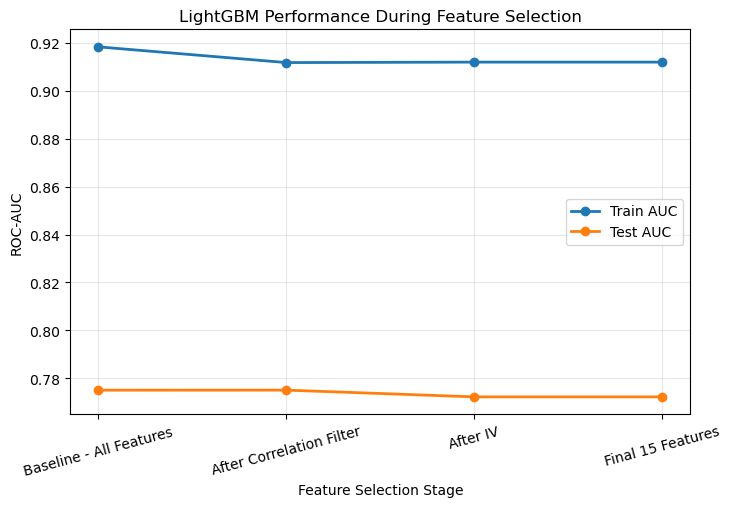

In [75]:
plt.figure(figsize=(8,5))
plt.plot(
    stage_results_df["Stage"],
    stage_results_df["Train AUC"],
    marker="o",
    linewidth=2,
    label="Train AUC"
)
plt.plot(
    stage_results_df["Stage"],
    stage_results_df["Test AUC"],
    marker="o",
    linewidth=2,
    label="Test AUC"
)

plt.xlabel("Feature Selection Stage")
plt.ylabel("ROC-AUC")
plt.title("LightGBM Performance During Feature Selection")
plt.xticks(rotation=15)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

###  Observation

Train AUC remains relatively stable at approximately **0.91** throughout the
feature-selection process.

Test AUC also remains stable, changing only slightly from **0.7750** with
23 features to **0.7723** with the final 15 features.

The correlation-filtered stage achieves the highest Test AUC of **0.7751**
using 16 features.

Overall, the results indicate that removing redundant and weakly informative
features had only a minor effect on predictive performance while producing
a more compact feature set.

## 14. Final Model Comparison and Hyperparameter Tuning

After completing the sequential feature-selection process, the final
**15 selected features** are used to train and compare six classification
algorithms.

The following models are evaluated:

- Logistic Regression
- Random Forest
- AdaBoost
- LightGBM
- CatBoost
- XGBoost

Each model is tuned using **GridSearchCV with Stratified 5-Fold
Cross-Validation**.

The models are evaluated using:

- Train ROC-AUC
- Test ROC-AUC
- Accuracy
- Precision
- Recall
- F1-score

The final model is selected primarily based on **Test ROC-AUC**, since the
objective is to identify the model with the strongest ability to distinguish
between default and non-default customers on unseen data

### 14.1 Initializing the Classification Models

Six classification algorithms are initialized for model benchmarking.

The comparison includes a linear baseline model, traditional ensemble
methods, and gradient-boosting algorithms. This provides a broader evaluation
of how different modeling approaches perform on the final selected features.

A fixed `random_state` is used where supported to improve reproducibility.

In [76]:
models = {
    "Logistic Regression":
        LogisticRegression(
            random_state=42,
            max_iter=1000
        ),
    "Random Forest":
        RandomForestClassifier(
            random_state=42
        ),
    "AdaBoost":
        AdaBoostClassifier(
            random_state=42
        ),
    "LightGBM":
        LGBMClassifier(
            random_state=42,
            verbosity=-1
        ),
    "CatBoost":
        CatBoostClassifier(
            random_state=42,
            verbose=0
        ),
    "XGBoost":
        XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        )
}

### 14.2 Defining the Hyperparameter Search Space

Each machine learning algorithm contains hyperparameters that control its
training behavior and model complexity.

A separate parameter grid is defined for each classifier.

`GridSearchCV` will systematically evaluate the specified combinations and
identify the configuration that achieves the strongest cross-validated
ROC-AUC score.

In [77]:
param_grid = {
    "Logistic Regression":{
        "C":[0.01,0.1,1,10]
    },
    "Random Forest":{
        "n_estimators":[100,200],
        "max_depth":[5,10,None]
    },
    "AdaBoost":{
        "n_estimators":[50,100],
        "learning_rate":[0.01,0.1,1]
    },
    "LightGBM":{
        "n_estimators":[100,200],
        "learning_rate":[0.01,0.05,0.1]
    },
    "CatBoost":{
        "depth":[4,6,8],
        "learning_rate":[0.01,0.05,0.1]
    },
    "XGBoost":{
        "max_depth":[3,5,7],
        "learning_rate":[0.01,0.1],
        "n_estimators":[100,200]
    }

}

### 14.3 Stratified 5-Fold Cross-Validation

**Stratified K-Fold Cross-Validation** is used during hyperparameter tuning.

The training dataset is divided into **5 folds**, while approximately
preserving the original proportion of default and non-default customers
within each fold.

For each hyperparameter configuration:

1. The model is trained using four folds.
2. The remaining fold is used for validation.
3. The process is repeated across all five folds.
4. The validation ROC-AUC scores are used to evaluate the configuration.

Shuffling is enabled and a fixed `random_state` is used to make the
cross-validation procedure reproducible.

In [78]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

### 14.4 Hyperparameter Tuning and Model Training

Each classifier is tuned using `GridSearchCV`.

For every model:

1. The predefined hyperparameter combinations are evaluated.
2. **ROC-AUC** is used as the optimization metric.
3. Stratified 5-Fold Cross-Validation is performed.
4. The best-performing hyperparameter configuration is selected.
5. The optimized model generates predictions on the training and testing sets.
6. Multiple evaluation metrics are calculated for final comparison.

The best estimator for each algorithm is also stored for later analysis.

In [79]:
# Store evaluation results and best estimators
results = []
best_models = {}

for name, model in models.items():
    
    print("="*60)
    print(name)
    print("="*60)

    # Search for the best hyperparameter combination
    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid[name],
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    )
    
    # Fit GridSearchCV using the final selected features
    grid.fit(
        X_train_final,
        y_train
    )
    
    # Retrieve and store the best estimator
    best_model = grid.best_estimator_
    best_models[name] = best_model

    # Predict probabilities for ROC-AUC
    train_prob = best_model.predict_proba(
        X_train_final
    )[:,1]

   
    test_prob = best_model.predict_proba(
        X_test_final
    )[:,1]
     
    # Generate class predictions
    train_pred = best_model.predict(
        X_train_final
    )
    test_pred = best_model.predict(
        X_test_final
    )

    # Store model evaluation metrics
    results.append({
        "Model":name,
        "Train AUC":
            roc_auc_score(
                y_train,
                train_prob
            ),
        "Test AUC":
            roc_auc_score(
                y_test,
                test_prob
            ),
        "Accuracy":
            accuracy_score(
                y_test,
                test_pred
            ),
        "Precision":
            precision_score(
                y_test,
                test_pred
            ),
        "Recall":
            recall_score(
                y_test,
                test_pred
            ),
        "F1":
            f1_score(
                y_test,
                test_pred
            )
    })
    print(
        "Best Parameters:",
        grid.best_params_
    )

Logistic Regression
Best Parameters: {'C': 0.01}
Random Forest
Best Parameters: {'max_depth': 10, 'n_estimators': 200}
AdaBoost
Best Parameters: {'learning_rate': 1, 'n_estimators': 100}
LightGBM
Best Parameters: {'learning_rate': 0.01, 'n_estimators': 200}
CatBoost
Best Parameters: {'depth': 8, 'learning_rate': 0.01}
XGBoost
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


### Best Hyperparameters

GridSearchCV identifies the following best hyperparameter configurations:

| Model | Best Hyperparameters |
|  ---  |       ---            |
| Logistic Regression|`C = 0.01`|
| Random Forest|`max_depth = 10`, `n_estimators = 200` |
| AdaBoost | `learning_rate = 1`, `n_estimators = 100` |
| LightGBM | `learning_rate = 0.01`, `n_estimators = 200` |
| CatBoost | `depth = 8`, `learning_rate = 0.01` |
| XGBoost | `learning_rate = 0.1`, `max_depth = 3`, `n_estimators = 100` |

These optimized configurations are used for the final performance comparison.

### 14.5 Model Performance Comparison

The optimized models are compared using their performance on the unseen
testing dataset.

The results are sorted by **Test ROC-AUC** from highest to lowest because
Test AUC is the primary model-selection metric for this project.

In [81]:
results_df = pd.DataFrame(
    results
)
results_df = results_df.sort_values(
    by="Test AUC",
    ascending=False
)
display(
    results_df.round(4)
)

,Model,Train AUC,Test AUC,Accuracy,Precision,Recall,F1
4,CatBoost,0.8529,0.7808,0.8160,0.6570,0.3521,0.4585
5,XGBoost,0.8011,0.7786,0.8172,0.6638,0.3521,0.4601
3,LightGBM,0.8154,0.7770,0.8169,0.6834,0.3209,0.4368
1,Random Forest,0.8585,0.7746,0.8163,0.6591,0.3516,0.4586
2,AdaBoost,0.7768,0.7683,0.8160,0.6754,0.3240,0.4379
0,Logistic Regression,0.7249,0.7119,0.8086,0.6909,0.2436,0.3602


### 💡 Model Comparison Results

| Model | Train AUC | Test AUC | Accuracy | Precision | Recall | F1 |
|  ---  |   ---:    |   ---:   |   ---:   |   ---:    |  ---:  |---:|
| **CatBoost**| **0.8529**| **0.7808**|0.8160|0.6570  |0.3521  |0.4585|
| XGBoost| 0.8011   | 0.7786   | 0.8172   | 0.6638    |0.3521|0.4601|
| LightGBM | 0.8154 | 0.7770 | 0.8169 | 0.6834 | 0.3209 | 0.4368 |
| Random Forest | 0.8585 | 0.7746 | 0.8163 | 0.6591 | 0.3516 | 0.4586 |
| AdaBoost | 0.7768 | 0.7683 | 0.8160 | 0.6754 | 0.3240 | 0.4379 |
| Logistic Regression | 0.7249 | 0.7119 | 0.8086 | 0.6909 | 0.2436 | 0.3602 |

**CatBoost achieves the highest Test ROC-AUC of 0.7808**, followed closely by
XGBoost with **0.7786** and LightGBM with **0.7770**.

Logistic Regression produces the lowest Test AUC at **0.7119**.

The results indicate that the tuned tree-based ensemble methods generally
provide stronger discrimination between default and non-default customers
than Logistic Regression for this dataset.

## 15. Best Model — CatBoost

The models are ranked according to **Test ROC-AUC**, and the classifier with
the highest score is selected as the final model.

Based on this criterion, **CatBoost** is the best-performing classifier.

In [82]:
best_name = results_df.iloc[0]["Model"]
print(
    "Best Model:",
    best_name
)

Best Model: CatBoost


### Why CatBoost Was Selected

**CatBoost achieves the highest Test ROC-AUC of 0.7808**, making it the
best-performing model according to the primary selection criterion.

The next closest models are:

- XGBoost - **0.7786**
- LightGBM - **0.7770**
- Random Forest - **0.7746**
- AdaBoost - **0.7683**
- Logistic Regression - **0.7119**

Although the differences among several ensemble models are relatively small,
CatBoost provides the strongest Test ROC-AUC and is therefore selected for
the final model analysis.

### 15.1 Test ROC-AUC Comparison

A bar chart is used to visually compare the Test ROC-AUC scores of the six
optimized classification models.

Higher bars represent stronger discrimination between default and
non-default customers on unseen test data.

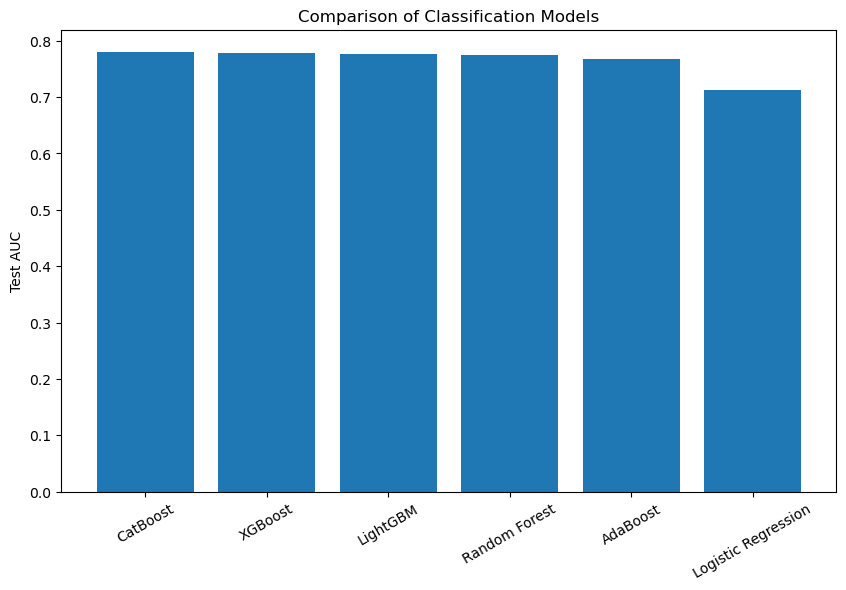

In [83]:
plt.figure(figsize=(10,6))
plt.bar(
    results_df["Model"],
    results_df["Test AUC"]
)
plt.xticks(rotation=30)
plt.ylabel("Test AUC")
plt.title("Comparison of Classification Models")
plt.show()

###  Observation

The ensemble models achieve relatively similar Test ROC-AUC scores, with
**CatBoost producing the highest value of 0.7808**.

XGBoost and LightGBM follow closely, while Logistic Regression shows a
noticeably lower Test AUC.

This visualization reinforces the final selection of CatBoost based on the
project's primary evaluation metric.

### 15.2 Confusion Matrix

A **confusion matrix** is used to examine how the final CatBoost model
classifies default and non-default customers.

The matrix separates predictions into four categories:

- **True Negative (TN):** Non-default customers correctly classified as non-default.
- **False Positive (FP):** Non-default customers incorrectly classified as default.
- **False Negative (FN):** Default customers incorrectly classified as non-default.
- **True Positive (TP):** Default customers correctly classified as default.

This provides more detail than accuracy alone by showing the types of
classification errors made by the model.

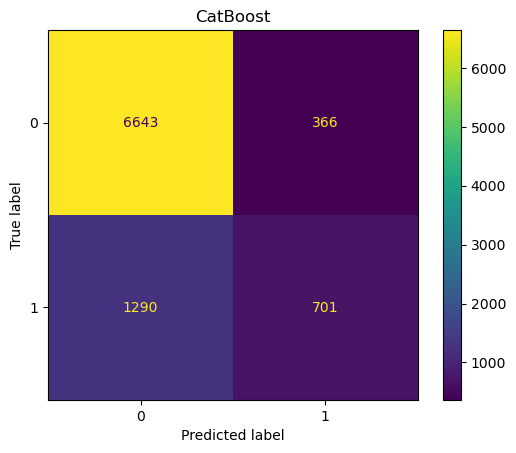

In [84]:
best_model = best_models[best_name]
predictions = best_model.predict(
    X_test_final
)
cm = confusion_matrix(
    y_test,
    predictions
)
ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()
plt.title(
    best_name
)
plt.show()

#### Observation

The confusion matrix shows that the model performs substantially better at
identifying **non-default customers (Class 0)** than **default customers
(Class 1)**.

This behavior is consistent with the class imbalance observed earlier in
the dataset, where non-default customers represent the majority class.

For a credit-default problem, the false negatives are particularly important
because they represent customers who actually defaulted but were predicted
as non-default.

### 16 Classification Report

The classification report provides class-specific measures of model
performance using **precision, recall, F1-score, and support**.

These metrics are particularly useful because the target variable is
imbalanced and accuracy alone may hide differences in performance between
the two classes.

In [85]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.84      0.95      0.89      7009
           1       0.66      0.35      0.46      1991

    accuracy                           0.82      9000
   macro avg       0.75      0.65      0.67      9000
weighted avg       0.80      0.82      0.79      9000



### Classification Report Interpretation

The CatBoost model achieves an overall accuracy of approximately **82%**.

For **Class 0 (Non-Default)**:

- Precision = **0.84**
- Recall = **0.95**
- F1-score = **0.89**

For **Class 1 (Default)**:

- Precision = **0.66**
- Recall = **0.35**
- F1-score = **0.46**

The model is considerably stronger at identifying non-default customers than
default customers.

The **0.35 recall for the default class** means that only about 35% of the
actual default cases are correctly identified at the classification threshold
used to generate these class predictions.

Therefore, although CatBoost provides the strongest ROC-AUC among the six
models, its ability to identify default cases at the current classification
threshold remains limited.

### 16.1 Final ROC Curve

The Receiver Operating Characteristic (**ROC**) curve evaluates the final
CatBoost model across different classification thresholds.

The curve plots:

- **False Positive Rate (FPR)** on the x-axis
- **True Positive Rate (TPR)** on the y-axis

The corresponding **ROC-AUC** summarizes the model's overall ability to
distinguish between default and non-default customers.

A model with stronger discriminative performance produces an ROC curve that
lies further above the diagonal random-classifier reference line.

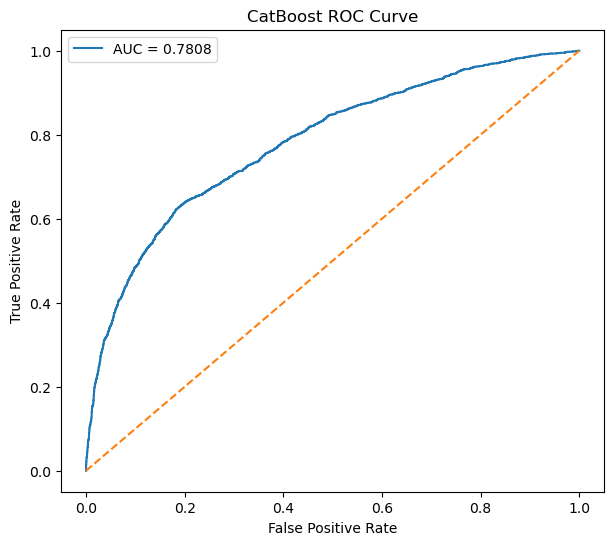

In [86]:
probabilities = best_model.predict_proba(
    X_test_final
)[:,1]

fpr,tpr,_ = roc_curve(
    y_test,
    probabilities
)
auc = roc_auc_score(
    y_test,
    probabilities
)

plt.figure(figsize=(7,6))
plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.4f}"
)
plt.plot(
    [0,1],
    [0,1],
    "--"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(
    f"{best_name} ROC Curve"
)
plt.legend()
plt.show()

###  16.2 Final ROC-AUC Interpretation

The CatBoost ROC curve lies above the diagonal random-classifier reference
line, demonstrating useful discrimination between the two target classes.

The final model achieves a **Test ROC-AUC of 0.7808**, the highest among the
six evaluated classifiers.

This means CatBoost provides the strongest overall ranking performance in
this model comparison, although its class-specific performance should also
be considered alongside ROC-AUC.

## 17. Final Project Summary

The complete machine learning pipeline combines sequential feature selection,
model explainability, hyperparameter tuning, and classifier benchmarking.

The feature-selection process reduced the original predictor set as follows:

**23 Original Features -> 16 After Correlation Filtering -> 15 After Information Value -> 15 Final SHAP-Ranked Features**

Six classification algorithms were then optimized and evaluated using the
final 15-feature dataset.

The final model comparison identified **CatBoost** as the strongest classifier
based on Test ROC-AUC.

In [87]:
print("="*25)
print("FINAL SUMMARY")
print("="*25)
print(
    "Original Features:",
    23
)
print(
    "After Correlation:",
    X_train_corr.shape[1]
)
print(
    "After IV:",
    X_train_iv.shape[1]
)
print(
    "Final Features:",
    X_train_final.shape[1]
)
print()
print(
    "Best Model:",
    best_name
)
print(
    "Best Test AUC:",
    round(
        results_df.iloc[0]["Test AUC"],
        4
    )
)

FINAL SUMMARY
Original Features: 23
After Correlation: 16
After IV: 15
Final Features: 15

Best Model: CatBoost
Best Test AUC: 0.7808


## 18. Conclusion

This project developed a machine learning pipeline for predicting credit card
payment default using **sequential feature selection and model benchmarking**.

The original dataset contained **23 predictor features**. A three-stage
feature-selection process was applied:

1. **Correlation Filtering** reduced the feature set from **23 to 16** by
   removing highly correlated and redundant predictors.

2. **Information Value (IV)** further reduced the feature set from
   **16 to 15** based on predictive separation between default and
   non-default customers.

3. **SHAP analysis** ranked the remaining 15 features according to their
   contribution to LightGBM predictions, with `PAY_0` identified as the
   most influential feature.

Using the final feature set, six classification algorithms were tuned using
**GridSearchCV with Stratified 5-Fold Cross-Validation**.

Among the evaluated models, **CatBoost achieved the highest Test ROC-AUC of
0.7808**, followed closely by XGBoost and LightGBM.

The results demonstrate that the predictor set could be reduced from
**23 to 15 features** while retaining competitive predictive performance.

However, the final CatBoost model achieved only approximately **35% recall
for the default class** at the classification threshold used in the notebook.
This indicates that further work could focus on improving the detection of
actual default customers while maintaining strong overall discrimination.

Overall, the project demonstrates an end-to-end workflow involving:

- Exploratory Data Analysis
- Correlation-Based Feature Selection
- Information Value and Weight of Evidence
- SHAP Model Explainability
- Sequential Feature Reduction
- Hyperparameter Optimization
- Cross-Validation
- Model Benchmarking
- Credit Default Prediction